# 05. Customer Lifetime Value Prediction  
## Time-Based Future Customer Value Modeling

This notebook builds a customer-level CLV prediction module for an e-commerce order-line analytics project.

The core question is:

> **Which customers are likely to generate higher future realized value?**

Here, CLV means **future realized revenue after returns**. 


# 1. Introduction and Business Objective

Customer Lifetime Value helps estimate which customers are likely to create stronger future value.

This module can support:

- loyalty and retention planning
- CRM campaign selection
- customer prioritization
- value-based segmentation
- identifying high-value customers whose return behavior weakens retained value

The model learns the relationship below:

```text
past customer behavior → future realized customer value
```

That design keeps the target future-facing and avoids ranking customers only by what they already spent.


# 2. Global Settings


In [1]:
from pathlib import Path
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.base import clone

import joblib

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

try:
    from lightgbm import LGBMRegressor
    LIGHTGBM_AVAILABLE = True
except Exception:
    LIGHTGBM_AVAILABLE = False

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

RANDOM_STATE = 42

MODEL_DIR = Path("models")
OUTPUT_DIR = Path("outputs")
MODEL_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

OBSERVATION_DAYS = 120
PREDICTION_DAYS = 90
SNAPSHOT_FREQ = "MS"
MIN_SNAPSHOT_CUSTOMERS = 50

TUNING_SAMPLE_SIZE = 50_000
PERMUTATION_SAMPLE_SIZE = 1_000
SCORING_SAMPLE_EXPORT_SIZE = 500_000


# 3. Data Loading



In [2]:
def load_any_data(path):
    """Load Parquet, CSV, CSV.GZ, or Excel based on file extension."""
    path = Path(path)
    suffixes = "".join(path.suffixes).lower()

    if suffixes.endswith(".parquet"):
        return pd.read_parquet(path)
    if suffixes.endswith(".csv") or suffixes.endswith(".csv.gz"):
        return pd.read_csv(path, low_memory=False)
    if suffixes.endswith(".xlsx") or suffixes.endswith(".xls"):
        return pd.read_excel(path)

    raise ValueError(f"Unsupported file type: {path}")


def load_schema_mapping():
    """Load the business-to-column schema mapping."""
    candidate_paths = [
        Path("schema_mapping.json"),
        Path("config/schema_mapping.json"),
        Path("../config/schema_mapping.json"),
    ]

    for path in candidate_paths:
        if path.exists():
            print(f"Loading schema mapping from: {path.as_posix()}")
            return json.loads(path.read_text())

    raise FileNotFoundError(
        "schema_mapping.json was not found. Place it in the notebook folder or config/."
    )


def load_orderline_data():
    """Load the available order-line dataset from common project paths."""
    candidate_paths = [
        Path("data/synthetic_orderline_2024.parquet"),
        Path("data/synthetic_orderline_2024.csv.gz"),
        Path("data/synthetic_orderline_2024_sample.csv.gz"),
        Path("../data/synthetic_orderline_2024.parquet"),
        Path("../data/synthetic_orderline_2024.csv.gz"),
        Path("../data/synthetic_orderline_2024_sample.csv.gz"),
        Path("synthetic_orderline_2024.parquet"),
        Path("synthetic_orderline_2024_sample.csv.gz"),
    ]

    for path in candidate_paths:
        if path.exists():
            print(f"Loading order-line data from: {path.as_posix()}")
            if "sample" in path.name.lower():
                print("Sample file detected. The notebook will run, but full datasets give stronger validation.")
            return load_any_data(path)

    raise FileNotFoundError(
        "No order-line dataset found. Place an order-line file in data/ or ../data/."
    )


SCHEMA = load_schema_mapping()
df_raw = load_orderline_data()

print("Raw dataset shape:", df_raw.shape)
display(df_raw.head())


Loading schema mapping from: ../config/schema_mapping.json
Loading order-line data from: ../data/synthetic_orderline_2024.parquet
Raw dataset shape: (4262864, 42)


,transaction_id,transaction_line_id,line_number,customer_key,item_key,session_key,order_timestamp,dispatch_timestamp,delivery_timestamp,return_timestamp,product_family,product_group,item_variant,size_code_public,color_group,assortment_type,customer_segment_seed,customer_region,loyalty_tier,customer_join_month,list_price,sale_price,net_revenue,realized_revenue,discount_amount,quantity,tax_rate,tax_amount,was_returned,return_reason_group,returned_quantity,returned_revenue,fulfillment_partner,delivery_mode,dispatch_delay_days,delivery_delay_days,acquisition_channel,campaign_group,traffic_source_group,order_year,order_month,order_weekday
0,TXN-2024-000000001,LINE-2024-0000000001,1,CUST-00245651,ITEM-0027199,SESS-2024-0000000001,2024-11-14 20:00:53,2024-11-15 20:00:53,2024-11-19 20:00:53,NaT,Office & Study,Organization,value,OneSize,neutral,core_range,high_return,Westport,gold,2024-07,14.400,11.770,23.540,23.540,5.260,2,0.000,0.000,0,not_returned,0,0.000,BoxBridge,standard,1,4,direct_web,always_on,search_engine,2024,11,Thursday
1,TXN-2024-000000001,LINE-2024-0000000002,2,CUST-00245651,ITEM-0057254,SESS-2024-0000000001,2024-11-14 20:00:53,2024-11-15 20:00:53,2024-11-19 20:00:53,NaT,Kids Essentials,Sleep,core,L,mixed,seasonal_range,high_return,Central Plains,gold,2024-09,31.710,31.710,31.710,31.710,0.000,1,0.190,6.020,0,not_returned,0,0.000,BoxBridge,standard,1,4,direct_web,always_on,comparison_site,2024,11,Thursday
2,TXN-2024-000000002,LINE-2024-0000000003,1,CUST-00452029,ITEM-0163028,SESS-2024-0000000002,2024-01-22 18:10:43,2024-01-23 18:10:43,2024-01-25 18:10:43,NaT,Digital Accessories,Cables,limited,OneSize,green,core_range,premium,Highland,platinum,2024-01,18.760,16.600,16.600,16.600,2.170,1,0.190,3.150,0,not_returned,0,0.000,UrbanRoute,express,1,2,organic_search,always_on,type_in,2024,1,Monday
3,TXN-2024-000000003,LINE-2024-0000000004,1,CUST-00014089,ITEM-0089146,SESS-2024-0000000003,2024-05-10 20:43:50,2024-05-12 20:43:50,2024-05-13 20:43:50,NaT,Everyday Apparel,Basics,core,L,not_applicable,core_range,premium,Metro Core,gold,2023-07,32.280,26.950,26.950,26.950,5.330,1,0.190,5.120,0,not_returned,0,0.000,EcoShip,express,2,1,email_campaign,always_on,social_feed,2024,5,Friday
4,TXN-2024-000000003,LINE-2024-0000000005,2,CUST-00014089,ITEM-0001754,SESS-2024-0000000003,2024-05-10 20:43:50,2024-05-12 20:43:50,2024-05-13 20:43:50,NaT,Beauty & Care,Wellness,premium,L,not_applicable,core_range,premium,Westport,gold,2022-11,15.700,15.700,15.700,15.700,0.000,1,0.210,3.300,0,not_returned,0,0.000,EcoShip,express,2,1,email_campaign,always_on,partner_site,2024,5,Friday


# 4. Data Validation and Date Preparation

The preparation focuses on:

- customer and transaction identifiers
- order timestamp
- realized revenue
- return flag
- product, channel, fulfillment, region, and loyalty fields where available

The target uses `realized_revenue`, because retained value after returns is more useful for CLV than purchase-time revenue alone.


In [3]:
def require_columns(df, cols, context="dataset"):
    """Raise a clear error if required columns are missing."""
    missing = [col for col in cols if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in {context}: {missing}")


def get_col(schema, key):
    """Return mapped column name when available."""
    return schema.get(key)


def prepare_clv_base_data(df, schema):
    """Prepare order-line data for CLV modeling using public-safe column names."""
    out = df.copy()

    customer_col = schema["customer_id"]
    order_col = schema["order_id"]
    date_col = schema["order_date"]
    realized_col = schema["realized_revenue"]

    required = [customer_col, order_col, date_col, realized_col]
    require_columns(out, required, context="CLV base data")

    # Dates
    date_cols = [
        schema.get("order_date"),
        schema.get("dispatch_date"),
        schema.get("delivery_date"),
        schema.get("return_date"),
    ]

    for col in date_cols:
        if col in out.columns:
            out[col] = pd.to_datetime(out[col], errors="coerce")

    out = out.dropna(subset=[customer_col, order_col, date_col]).copy()

    # Return flag
    return_col = schema.get("return_flag")
    return_date_col = schema.get("return_date")

    if return_col in out.columns:
        out[return_col] = pd.to_numeric(out[return_col], errors="coerce").fillna(0).astype(int)
    elif return_date_col in out.columns:
        out[return_col] = out[return_date_col].notna().astype(int)
    else:
        out[return_col] = 0

    # Realized revenue fallback if needed
    net_col = schema.get("original_revenue")

    if realized_col not in out.columns and net_col in out.columns:
        out[realized_col] = np.where(out[return_col] == 1, 0, out[net_col])

    out[realized_col] = pd.to_numeric(out[realized_col], errors="coerce").fillna(0)
    out[realized_col] = out[realized_col].clip(lower=0)

    # Numeric conversions
    numeric_keys = [
        "original_revenue", "realized_revenue", "quantity", "price", "list_price",
        "discount", "tax_rate", "tax_amount", "shipping_delay", "dispatch_delay"
    ]

    for key in numeric_keys:
        col = schema.get(key)
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    # Helpful time fields
    out["order_month_period"] = out[date_col].dt.to_period("M").astype(str)
    out["order_month"] = out[date_col].dt.month
    out["order_weekday"] = out[date_col].dt.day_name()

    return out


analysis_df = prepare_clv_base_data(df_raw, SCHEMA)

customer_col = SCHEMA["customer_id"]
order_col = SCHEMA["order_id"]
date_col = SCHEMA["order_date"]
realized_col = SCHEMA["realized_revenue"]
return_col = SCHEMA["return_flag"]

print("Prepared dataset shape:", analysis_df.shape)
print("Date range:", analysis_df[date_col].min(), "to", analysis_df[date_col].max())
print("Unique customers:", analysis_df[customer_col].nunique())
print("Unique transactions:", analysis_df[order_col].nunique())
print("Total realized revenue:", analysis_df[realized_col].sum())
print("Return rate:", analysis_df[return_col].mean())


Prepared dataset shape: (4262864, 43)
Date range: 2024-01-01 00:00:27 to 2024-12-31 23:59:32
Unique customers: 430113
Unique transactions: 2254806
Total realized revenue: 142747822.01
Return rate: 0.11040112938156131


# 5. CLV Definition and Time-Window Design

I treat CLV as future realized value.

For each snapshot date:

```text
observation window → customer features
prediction window  → future CLV target
```

The target is:

```text
future_realized_clv = sum(realized_revenue) in the prediction window
```

Features come only from the observation window. The CLV target comes only from the future prediction window, which helps avoid leakage.

The default setup uses:

```python
OBSERVATION_DAYS = 120
PREDICTION_DAYS = 90
SNAPSHOT_FREQ = "MS"
```

Longer windows are usually more stable, while shorter windows create more snapshots. 


In [4]:
def generate_snapshot_dates(df, schema, observation_days=120, prediction_days=90, freq="MS"):
    """Generate snapshot dates where both observation and prediction windows are available."""
    date_col = schema["order_date"]

    min_date = df[date_col].min()
    max_date = df[date_col].max()

    first_snapshot = min_date + pd.Timedelta(days=observation_days)
    last_snapshot = max_date - pd.Timedelta(days=prediction_days)

    if first_snapshot > last_snapshot:
        return pd.DatetimeIndex([]), min_date, max_date, first_snapshot, last_snapshot

    return pd.date_range(first_snapshot, last_snapshot, freq=freq), min_date, max_date, first_snapshot, last_snapshot


def choose_snapshot_windows(df, schema, preferred_observation_days, preferred_prediction_days, freq="MS"):
    """Choose practical snapshot windows for the available date range."""
    candidate_windows = [
        (preferred_observation_days, preferred_prediction_days),
        (120, 90),
        (90, 60),
        (60, 30),
    ]

    seen = set()
    unique_candidates = []

    for obs_days, pred_days in candidate_windows:
        key = (obs_days, pred_days)
        if key not in seen:
            seen.add(key)
            unique_candidates.append(key)

    for obs_days, pred_days in unique_candidates:
        dates, min_date, max_date, first_snapshot, last_snapshot = generate_snapshot_dates(
            df, schema, obs_days, pred_days, freq
        )
        if len(dates) > 0:
            return dates, min_date, max_date, first_snapshot, last_snapshot, obs_days, pred_days

    obs_days, pred_days = unique_candidates[-1]
    dates, min_date, max_date, first_snapshot, last_snapshot = generate_snapshot_dates(
        df, schema, obs_days, pred_days, freq
    )

    return dates, min_date, max_date, first_snapshot, last_snapshot, obs_days, pred_days


snapshot_dates, min_date, max_date, first_snapshot, last_snapshot, selected_obs_days, selected_pred_days = choose_snapshot_windows(
    analysis_df,
    SCHEMA,
    OBSERVATION_DAYS,
    PREDICTION_DAYS,
    SNAPSHOT_FREQ
)

OBSERVATION_DAYS = selected_obs_days
PREDICTION_DAYS = selected_pred_days

print("Data range:", min_date.date(), "to", max_date.date())
print("Selected observation window days:", OBSERVATION_DAYS)
print("Selected prediction window days:", PREDICTION_DAYS)
print("First possible snapshot:", first_snapshot.date())
print("Last possible snapshot:", last_snapshot.date())
print("Number of snapshot dates:", len(snapshot_dates))

if len(snapshot_dates) == 0:
    raise ValueError(
        "No valid snapshot dates were produced. Try reducing OBSERVATION_DAYS or PREDICTION_DAYS."
    )


Data range: 2024-01-01 to 2024-12-31
Selected observation window days: 120
Selected prediction window days: 90
First possible snapshot: 2024-04-30
Last possible snapshot: 2024-10-02
Number of snapshot dates: 6


# 6. Build Customer Snapshot Dataset

Each row in the snapshot dataset represents one customer at one snapshot date.

The feature window looks backward from the snapshot date. The target window looks forward from the snapshot date.

Customers with zero future CLV are kept. They are part of the real prediction problem because many customers do not buy again within a fixed future window.


In [5]:
def safe_mode(series):
    """Return most common value, or Unknown if no value is available."""
    clean = series.dropna()
    if clean.empty:
        return "Unknown"
    return clean.astype(str).mode().iloc[0]


def average_days_between_dates(date_series):
    """Average days between unique ordered dates."""
    dates = pd.Series(date_series).dropna().drop_duplicates().sort_values()
    if len(dates) < 2:
        return np.nan
    return dates.diff().dt.days.dropna().mean()


def build_valid_order_table(data, schema):
    """Build transaction-level validity table.

    A valid transaction contains at least one non-returned line.
    Fully returned transactions are kept as a separate signal.
    """
    customer_col = schema["customer_id"]
    order_col = schema["order_id"]
    date_col = schema["order_date"]
    return_col = schema["return_flag"]
    realized_col = schema["realized_revenue"]

    order_table = (
        data.groupby([customer_col, order_col])
        .agg(
            order_date=(date_col, "max"),
            order_lines=(order_col, "size"),
            non_returned_lines=(return_col, lambda x: int((x == 0).sum())),
            returned_lines=(return_col, "sum"),
            order_realized_revenue=(realized_col, "sum"),
        )
        .reset_index()
    )

    order_table["is_valid_order"] = (order_table["non_returned_lines"] > 0).astype(int)
    order_table["is_fully_returned_order"] = (order_table["non_returned_lines"] == 0).astype(int)

    return order_table


def _safe_nunique(series):
    return series.dropna().nunique()


def build_customer_clv_snapshot(df, schema, snapshot_date, observation_days=120, prediction_days=90):
    """Build one customer-level feature-target table for a snapshot date."""
    customer_col = schema["customer_id"]
    order_col = schema["order_id"]
    order_line_col = schema["order_line_id"]
    item_col = schema["item_id"]
    date_col = schema["order_date"]
    realized_col = schema["realized_revenue"]
    return_col = schema["return_flag"]
    net_col = schema.get("original_revenue")

    obs_start = snapshot_date - pd.Timedelta(days=observation_days)
    obs_end = snapshot_date
    pred_start = snapshot_date
    pred_end = snapshot_date + pd.Timedelta(days=prediction_days)

    obs = df[(df[date_col] >= obs_start) & (df[date_col] < obs_end)].copy()
    pred = df[(df[date_col] >= pred_start) & (df[date_col] < pred_end)].copy()

    if obs.empty:
        return pd.DataFrame()

    obs_orders = build_valid_order_table(obs, schema)
    pred_orders = build_valid_order_table(pred, schema) if not pred.empty else pd.DataFrame(
        columns=[customer_col, order_col, "is_valid_order"]
    )

    # Basic customer-line features
    agg_dict = {
        "total_order_lines": (order_line_col, "count") if order_line_col in obs.columns else (order_col, "size"),
        "returned_order_lines": (return_col, "sum"),
        "unique_orders": (order_col, "nunique"),
        "monetary": (realized_col, "sum"),
        "avg_line_revenue": (realized_col, "mean"),
        "first_order_date": (date_col, "min"),
        "last_order_date": (date_col, "max"),
        "active_months": ("order_month_period", "nunique"),
    }

    optional_nunique = {
        "unique_products": schema.get("item_id"),
        "unique_product_families": schema.get("product_category"),
        "unique_channels": schema.get("channel"),
        "unique_carriers": schema.get("carrier"),
    }

    for output_col, source_col in optional_nunique.items():
        if source_col in obs.columns:
            agg_dict[output_col] = (source_col, _safe_nunique)

    optional_means = {
        "avg_quantity": schema.get("quantity"),
        "avg_price": schema.get("price"),
        "avg_discount": schema.get("discount"),
        "avg_dispatch_delay": schema.get("dispatch_delay"),
        "avg_delivery_delay": schema.get("shipping_delay"),
    }

    for output_col, source_col in optional_means.items():
        if source_col in obs.columns:
            agg_dict[output_col] = (source_col, "mean")

    if net_col in obs.columns:
        agg_dict["net_revenue"] = (net_col, "sum")

    if "returned_revenue" in obs.columns:
        agg_dict["returned_revenue"] = ("returned_revenue", "sum")

    customer_features = obs.groupby(customer_col).agg(**agg_dict).reset_index()

    valid_order_counts = (
        obs_orders.groupby(customer_col)
        .agg(
            valid_orders=("is_valid_order", "sum"),
            fully_returned_orders=("is_fully_returned_order", "sum"),
            order_count=("is_valid_order", "size"),
        )
        .reset_index()
    )

    customer_features = customer_features.merge(valid_order_counts, on=customer_col, how="left")

    customer_features["frequency"] = customer_features["valid_orders"].fillna(0)
    customer_features["non_returned_order_lines"] = (
        customer_features["total_order_lines"] - customer_features["returned_order_lines"]
    ).clip(lower=0)

    customer_features["recency_days"] = (snapshot_date - customer_features["last_order_date"]).dt.days
    customer_features["customer_age_days"] = (
        customer_features["last_order_date"] - customer_features["first_order_date"]
    ).dt.days + 1
    customer_features["days_between_first_last_order"] = (
        customer_features["last_order_date"] - customer_features["first_order_date"]
    ).dt.days
    customer_features["months_since_first_order"] = (
        (snapshot_date - customer_features["first_order_date"]).dt.days / 30.4375
    )

    customer_features["return_rate"] = np.where(
        customer_features["total_order_lines"] > 0,
        customer_features["returned_order_lines"] / customer_features["total_order_lines"],
        0,
    )

    customer_features["purchase_rate"] = customer_features["frequency"] / observation_days
    customer_features["avg_order_value"] = np.where(
        customer_features["frequency"] > 0,
        customer_features["monetary"] / customer_features["frequency"],
        0,
    )

    if "net_revenue" in customer_features.columns:
        customer_features["returned_revenue_share"] = np.where(
            customer_features["net_revenue"] > 0,
            (customer_features["net_revenue"] - customer_features["monetary"]).clip(lower=0) / customer_features["net_revenue"],
            0,
        )
        customer_features["realized_to_net_revenue_ratio"] = np.where(
            customer_features["net_revenue"] > 0,
            customer_features["monetary"] / customer_features["net_revenue"],
            0,
        )
    else:
        customer_features["returned_revenue_share"] = customer_features["return_rate"]
        customer_features["realized_to_net_revenue_ratio"] = 1 - customer_features["return_rate"]

    customer_features["full_return_customer_flag"] = (
        (customer_features["frequency"] == 0) & (customer_features["monetary"] == 0)
    ).astype(int)
    customer_features["high_return_customer_flag"] = (customer_features["return_rate"] >= 0.50).astype(int)

    # Timing behavior
    avg_days = (
        obs_orders.groupby(customer_col)["order_date"]
        .apply(average_days_between_dates)
        .rename("average_days_between_orders")
        .reset_index()
    )
    customer_features = customer_features.merge(avg_days, on=customer_col, how="left")

    customer_features["last_order_month"] = customer_features["last_order_date"].dt.month
    customer_features["last_order_weekday"] = customer_features["last_order_date"].dt.day_name()

    # Main categorical preferences
    mode_features = {
        "main_channel": schema.get("channel"),
        "main_product_family": schema.get("product_category"),
        "main_carrier": schema.get("carrier"),
        "loyalty_tier": schema.get("loyalty_tier"),
        "customer_region": schema.get("customer_region"),
    }

    for output_col, source_col in mode_features.items():
        if source_col in obs.columns:
            mode_table = obs.groupby(customer_col)[source_col].apply(safe_mode).rename(output_col).reset_index()
            customer_features = customer_features.merge(mode_table, on=customer_col, how="left")

    # Alias count names used in downstream analysis
    if "unique_product_families" in customer_features.columns:
        customer_features["product_family_count"] = customer_features["unique_product_families"]
    if "unique_channels" in customer_features.columns:
        customer_features["channel_count"] = customer_features["unique_channels"]
    if "unique_carriers" in customer_features.columns:
        customer_features["carrier_count"] = customer_features["unique_carriers"]
    if "unique_products" in customer_features.columns:
        customer_features["item_count"] = customer_features["unique_products"]

    # Future target
    if not pred.empty:
        future_value = (
            pred.groupby(customer_col)[realized_col]
            .sum()
            .rename("future_realized_clv")
            .reset_index()
        )
    
        future_order_count = (
            pred.groupby(customer_col)[order_col]
            .nunique()
            .rename("future_order_count")
            .reset_index()
        )
    else:
        future_value = pd.DataFrame(columns=[customer_col, "future_realized_clv"])
        future_order_count = pd.DataFrame(columns=[customer_col, "future_order_count"])
    
    if not pred_orders.empty:
        future_valid_orders = (
            pred_orders.groupby(customer_col)["is_valid_order"]
            .sum()
            .rename("future_valid_orders")
            .reset_index()
        )
    else:
        future_valid_orders = pd.DataFrame(columns=[customer_col, "future_valid_orders"])
    
    snapshot = customer_features.merge(future_value, on=customer_col, how="left")
    snapshot = snapshot.merge(future_order_count, on=customer_col, how="left")
    snapshot = snapshot.merge(future_valid_orders, on=customer_col, how="left")

    snapshot["future_realized_clv"] = pd.to_numeric(
        snapshot["future_realized_clv"],
        errors="coerce"
    ).fillna(0.0)
    
    snapshot["future_order_count"] = pd.to_numeric(
        snapshot["future_order_count"],
        errors="coerce"
    ).fillna(0.0)
    
    snapshot["future_valid_orders"] = pd.to_numeric(
        snapshot["future_valid_orders"],
        errors="coerce"
    ).fillna(0.0)
    
    snapshot["future_active_flag"] = (snapshot["future_realized_clv"] > 0).astype(int)
    
    snapshot["target_eur"] = snapshot["future_realized_clv"].astype(float)
    snapshot["target_log"] = np.log1p(snapshot["target_eur"].clip(lower=0))
    
    snapshot["snapshot_date"] = snapshot_date
    snapshot["observation_start"] = obs_start
    snapshot["prediction_end"] = pred_end

    return snapshot


In [6]:
snapshot_frames = []

for snapshot_date in snapshot_dates:
    snapshot = build_customer_clv_snapshot(
        analysis_df,
        SCHEMA,
        snapshot_date=snapshot_date,
        observation_days=OBSERVATION_DAYS,
        prediction_days=PREDICTION_DAYS,
    )

    if len(snapshot) >= MIN_SNAPSHOT_CUSTOMERS:
        snapshot_frames.append(snapshot)

if not snapshot_frames:
    raise ValueError(
        "No customer snapshots were built. Try reducing MIN_SNAPSHOT_CUSTOMERS or changing the window design."
    )

customer_snapshot_df = pd.concat(snapshot_frames, ignore_index=True)

print("Customer snapshot dataset shape:", customer_snapshot_df.shape)
print("Unique snapshot dates:", customer_snapshot_df["snapshot_date"].nunique())
print("Unique customers:", customer_snapshot_df[SCHEMA["customer_id"]].nunique())

display(customer_snapshot_df.head())


Customer snapshot dataset shape: (1723287, 57)
Unique snapshot dates: 6
Unique customers: 389525


,customer_key,total_order_lines,returned_order_lines,unique_orders,monetary,avg_line_revenue,first_order_date,last_order_date,active_months,unique_products,unique_product_families,unique_channels,unique_carriers,avg_quantity,avg_price,avg_discount,avg_dispatch_delay,avg_delivery_delay,net_revenue,returned_revenue,valid_orders,fully_returned_orders,order_count,frequency,non_returned_order_lines,recency_days,customer_age_days,days_between_first_last_order,months_since_first_order,return_rate,purchase_rate,avg_order_value,returned_revenue_share,realized_to_net_revenue_ratio,full_return_customer_flag,high_return_customer_flag,average_days_between_orders,last_order_month,last_order_weekday,main_channel,main_product_family,main_carrier,loyalty_tier,customer_region,product_family_count,channel_count,carrier_count,item_count,future_realized_clv,future_order_count,future_valid_orders,future_active_flag,target_eur,target_log,snapshot_date,observation_start,prediction_end
0,CUST-00000001,1,0,1,47.450,47.450,2024-01-29 19:56:06,2024-01-29 19:56:06,1,1,1,1,1,2.000,23.730,11.950,0.000,7.000,47.450,0.000,1,0,1,1,1,92,1,0,3.023,0.000,0.008,47.450,0.000,1.000,0,0,NaN,1,Monday,organic_search,Digital Accessories,UrbanRoute,bronze,Southridge,1,1,1,1,57.990,1.000,1.000,1,57.990,4.077,2024-05-01 00:00:27,2024-01-02 00:00:27,2024-07-30 00:00:27
1,CUST-00000004,7,0,2,146.390,20.913,2024-02-10 17:21:33,2024-04-25 18:45:42,2,7,5,2,2,1.429,17.233,8.306,0.857,3.714,146.390,0.000,2,0,2,2,7,5,76,75,2.628,0.000,0.017,73.195,0.000,1.000,0,0,75.000,4,Thursday,social_media,Active Lifestyle,EcoShip,gold,Highland,5,2,2,7,326.570,3.000,3.000,1,326.570,5.792,2024-05-01 00:00:27,2024-01-02 00:00:27,2024-07-30 00:00:27
2,CUST-00000007,2,0,1,70.860,35.430,2024-02-27 15:44:46,2024-02-27 15:44:46,1,2,2,1,1,1.500,20.235,0.000,0.000,1.000,70.860,0.000,1,0,1,1,2,63,1,0,2.070,0.000,0.008,70.860,0.000,1.000,0,0,NaN,2,Tuesday,email_campaign,Everyday Apparel,EcoShip,bronze,Northlake,2,1,1,2,0.000,0.000,0.000,0,0.000,0.000,2024-05-01 00:00:27,2024-01-02 00:00:27,2024-07-30 00:00:27
3,CUST-00000008,6,0,2,172.000,28.667,2024-02-26 15:10:47,2024-03-24 10:53:59,2,6,3,2,2,1.333,23.055,8.012,0.000,3.000,172.000,0.000,2,0,2,2,6,37,27,26,2.103,0.000,0.017,86.000,0.000,1.000,0,0,26.000,3,Sunday,paid_search,Office & Study,MetroFulfill,gold,Coastal Belt,3,2,2,6,0.000,1.000,0.000,0,0.000,0.000,2024-05-01 00:00:27,2024-01-02 00:00:27,2024-07-30 00:00:27
4,CUST-00000009,1,0,1,12.190,12.190,2024-03-02 15:18:45,2024-03-02 15:18:45,1,1,1,1,1,1.000,12.190,4.480,1.000,4.000,12.190,0.000,1,0,1,1,1,59,1,0,1.938,0.000,0.008,12.190,0.000,1.000,0,0,NaN,3,Saturday,paid_search,Pet Lifestyle,NorthStar Logistics,new,Eastvale,1,1,1,1,0.000,0.000,0.000,0,0.000,0.000,2024-05-01 00:00:27,2024-01-02 00:00:27,2024-07-30 00:00:27


## Target Validation

A meaningful CLV setup should include enough customers, enough snapshots, and a realistic mix of zero and positive future value.


In [7]:
target_validation = pd.DataFrame({
    "total_customer_snapshots": [len(customer_snapshot_df)],
    "unique_customers": [customer_snapshot_df[SCHEMA["customer_id"]].nunique()],
    "observation_window_days": [OBSERVATION_DAYS],
    "prediction_window_days": [PREDICTION_DAYS],
    "first_snapshot_date": [customer_snapshot_df["snapshot_date"].min()],
    "last_snapshot_date": [customer_snapshot_df["snapshot_date"].max()],
    "share_zero_future_clv": [(customer_snapshot_df["target_eur"] == 0).mean()],
    "average_future_clv": [customer_snapshot_df["target_eur"].mean()],
    "median_future_clv": [customer_snapshot_df["target_eur"].median()],
    "p90_future_clv": [customer_snapshot_df["target_eur"].quantile(0.90)],
    "total_future_clv": [customer_snapshot_df["target_eur"].sum()],
})

display(target_validation)


,total_customer_snapshots,unique_customers,observation_window_days,prediction_window_days,first_snapshot_date,last_snapshot_date,share_zero_future_clv,average_future_clv,median_future_clv,p90_future_clv,total_future_clv
0,1723287,389525,120,90,2024-05-01 00:00:27,2024-10-01 00:00:27,0.351,102.055,44.480,288.090,"175,869,810.830"


**Interpretation**

The snapshot dataset contains **1.72M customer snapshots** across **389.5K customers** and six snapshot dates. About **35.1%** of snapshots have zero future CLV, while the average future CLV is about **€102** and the median is about **€44**.

This skew is expected in customer-value modeling. Many customers generate no value in the prediction window, while a smaller group accounts for much higher future value. For that reason, I evaluate the model both as a euro prediction problem and as a ranking problem.


# 7. Customer-Level Feature Engineering

The snapshot table already contains customer-level features built from the observation window.

Feature groups include:

- RFM-R behavior
- transaction and product diversity
- return and value-quality behavior
- timing behavior
- channel, product-family, fulfillment, region, and loyalty context where available

Prediction-window information is excluded from model features.


In [8]:
feature_group_summary = {
    "RFM-R": ["recency_days", "frequency", "monetary", "return_rate"],
    "Behavior": [
        "total_order_lines", "returned_order_lines", "non_returned_order_lines",
        "unique_orders", "valid_orders", "fully_returned_orders",
        "unique_products", "unique_product_families", "active_months",
        "purchase_rate", "avg_order_value", "avg_line_revenue",
    ],
    "Timing": [
        "customer_age_days", "days_between_first_last_order",
        "average_days_between_orders", "last_order_month", "last_order_weekday",
        "months_since_first_order",
    ],
    "Value quality": [
        "returned_revenue_share", "full_return_customer_flag",
        "realized_to_net_revenue_ratio", "high_return_customer_flag",
    ],
    "Context": [
        "main_channel", "main_product_family", "main_carrier",
        "loyalty_tier", "customer_region",
    ],
}

for group, cols in feature_group_summary.items():
    available = [col for col in cols if col in customer_snapshot_df.columns]
    print(f"{group}: {available}")


RFM-R: ['recency_days', 'frequency', 'monetary', 'return_rate']
Behavior: ['total_order_lines', 'returned_order_lines', 'non_returned_order_lines', 'unique_orders', 'valid_orders', 'fully_returned_orders', 'unique_products', 'unique_product_families', 'active_months', 'purchase_rate', 'avg_order_value', 'avg_line_revenue']
Timing: ['customer_age_days', 'days_between_first_last_order', 'average_days_between_orders', 'last_order_month', 'last_order_weekday', 'months_since_first_order']
Value quality: ['returned_revenue_share', 'full_return_customer_flag', 'realized_to_net_revenue_ratio', 'high_return_customer_flag']
Context: ['main_channel', 'main_product_family', 'main_carrier', 'loyalty_tier', 'customer_region']


# 8. Exploratory CLV Analysis

Before modeling, we check how future CLV changes across customer behavior groups. The goal is to see whether recency, frequency, monetary value, return behavior, channel, product family, and loyalty context carry useful signal for future customer value.


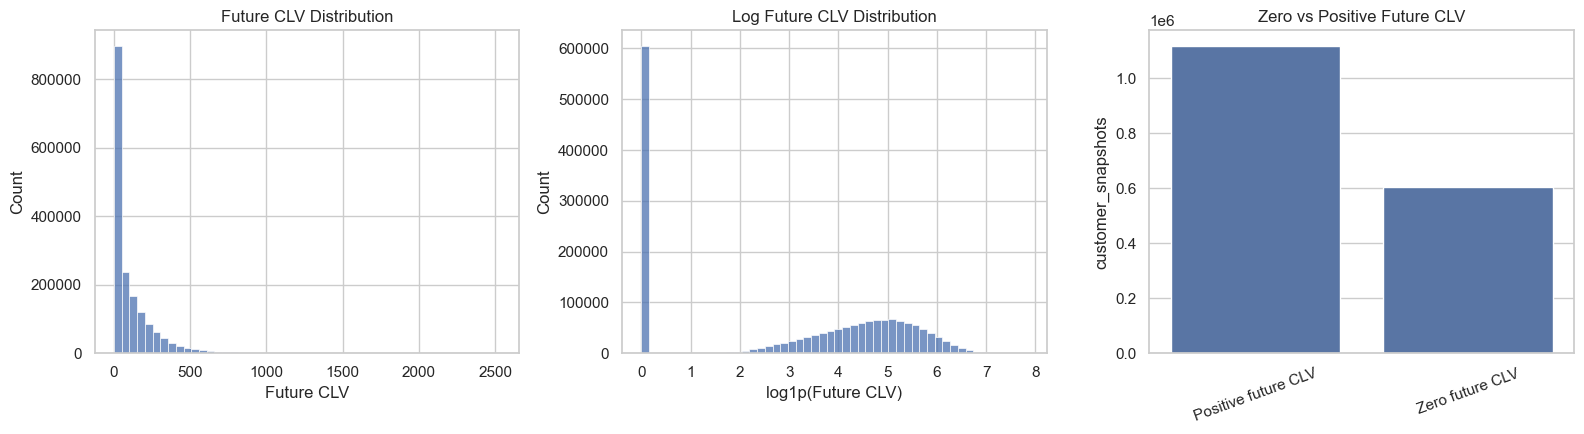

,future_value_group,customer_snapshots
0,Positive future CLV,1118128
1,Zero future CLV,605159


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(customer_snapshot_df["target_eur"], bins=50, ax=axes[0])
axes[0].set_title("Future CLV Distribution")
axes[0].set_xlabel("Future CLV")

sns.histplot(customer_snapshot_df["target_log"], bins=50, ax=axes[1])
axes[1].set_title("Log Future CLV Distribution")
axes[1].set_xlabel("log1p(Future CLV)")

zero_positive = (
    customer_snapshot_df.assign(future_value_group=np.where(customer_snapshot_df["target_eur"] > 0, "Positive future CLV", "Zero future CLV"))
    .groupby("future_value_group")
    .size()
    .reset_index(name="customer_snapshots")
)

sns.barplot(data=zero_positive, x="future_value_group", y="customer_snapshots", ax=axes[2])
axes[2].set_title("Zero vs Positive Future CLV")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

display(zero_positive)


The target distribution is highly uneven. There are about **1.12M positive future-CLV snapshots** and **605K zero future-CLV snapshots**. This matters because a CLV model needs to handle both questions at once: which customers are likely to buy again, and how much value they may generate if they do.


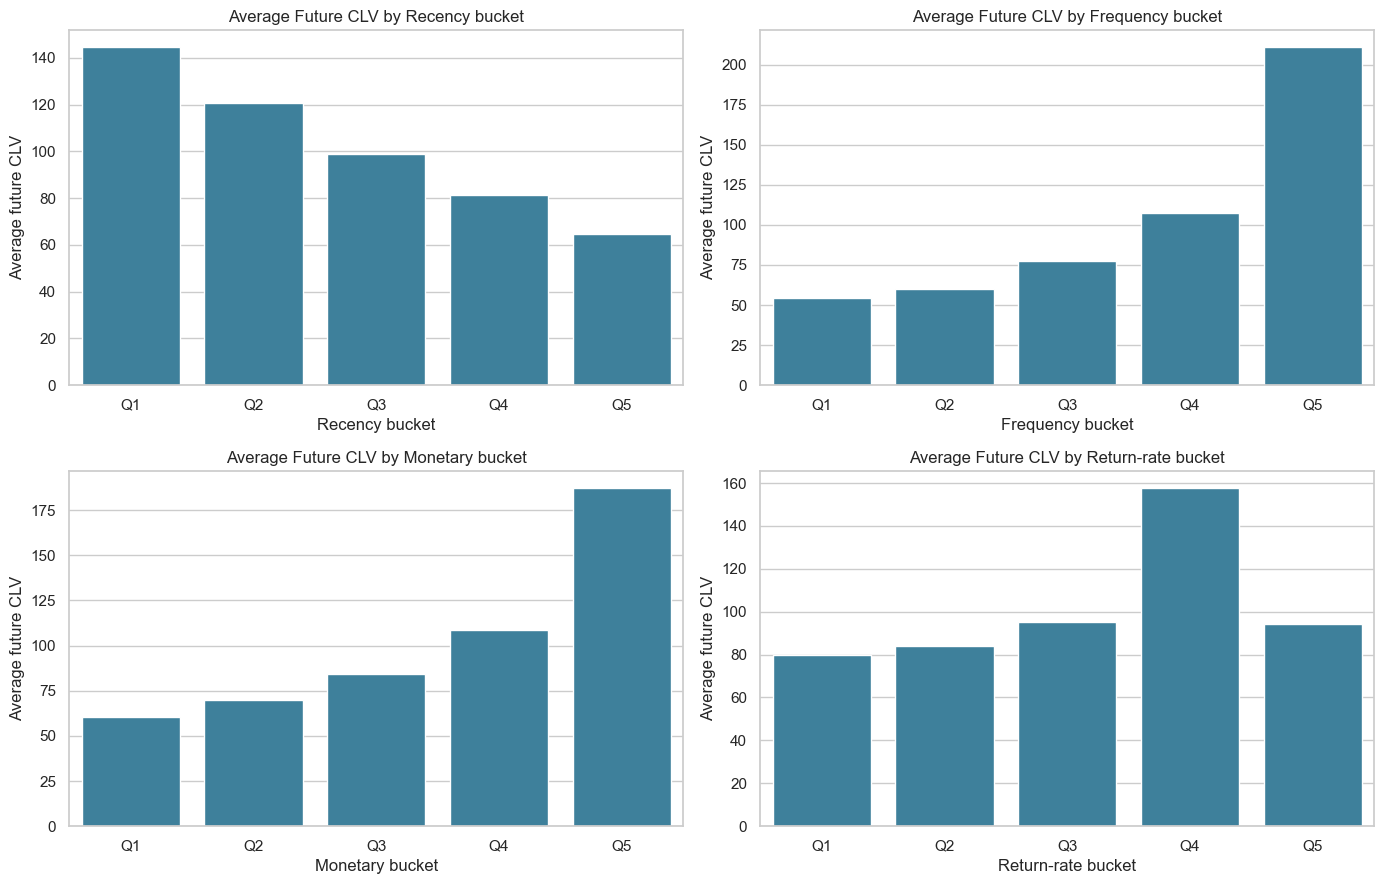

In [10]:
def safe_quantile_bucket(series, q=5, labels=None):
    """Create robust quantile buckets for skewed or repeated values."""
    if labels is None:
        labels = [f"Q{i}" for i in range(1, q + 1)]

    clean = series.copy()

    try:
        return pd.qcut(clean.rank(method="first"), q=q, labels=labels)
    except Exception:
        return pd.cut(clean.rank(method="first"), bins=q, labels=labels)


bucket_config = [
    ("recency_days", "Recency bucket"),
    ("frequency", "Frequency bucket"),
    ("monetary", "Monetary bucket"),
    ("return_rate", "Return-rate bucket"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, (col, title) in zip(axes.flatten(), bucket_config):
    if col in customer_snapshot_df.columns:
        plot_df = customer_snapshot_df.copy()
        plot_df[f"{col}_bucket"] = safe_quantile_bucket(plot_df[col], q=5)

        summary = (
            plot_df.groupby(f"{col}_bucket", observed=False)
            .agg(avg_future_clv=("target_eur", "mean"), snapshots=("target_eur", "size"))
            .reset_index()
        )

        sns.barplot(data=summary, x=f"{col}_bucket", y="avg_future_clv", ax=ax, color="#2E86AB")
        ax.set_title(f"Average Future CLV by {title}")
        ax.set_xlabel(title)
        ax.set_ylabel("Average future CLV")

plt.tight_layout()
plt.show()


The bucket charts give a quick check of whether customer behavior separates future value. Frequency and monetary buckets show the clearest CLV separation, while recency also carries useful signal. Return-rate buckets are better read as value-quality context rather than a complete CLV explanation on their own. This supports the modeling approach: CLV should combine purchase intensity, retained value, timing, and return behavior instead of relying on one metric.


,main_channel,customer_snapshots,avg_future_clv,median_future_clv,avg_return_rate
0,direct_web,466796,109.156,49.890,0.093
1,organic_search,297553,101.591,43.830,0.101
2,affiliate_partner,156560,101.580,46.300,0.111
3,email_campaign,215982,100.097,44.160,0.089
4,paid_search,239947,99.392,41.370,0.110
5,marketplace,166676,97.698,41.470,0.122
6,social_media,179773,94.743,37.810,0.125


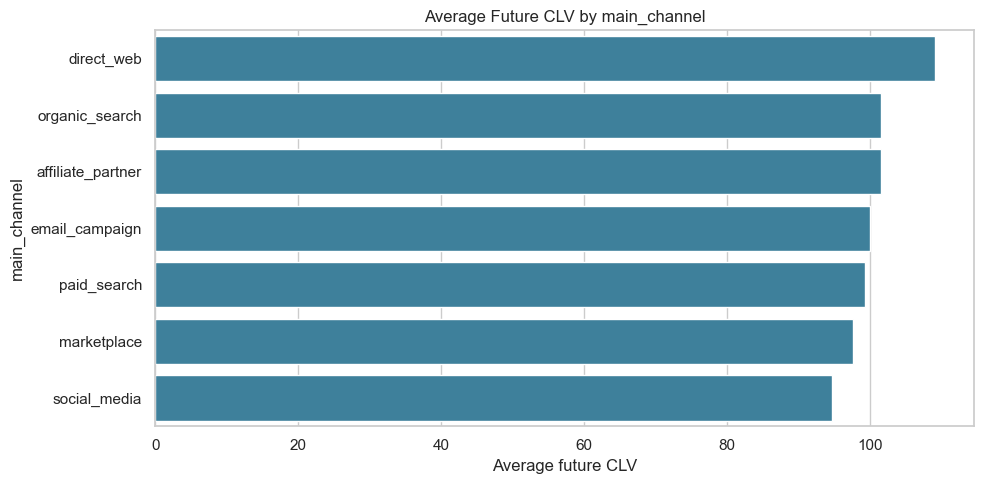

,main_product_family,customer_snapshots,avg_future_clv,median_future_clv,avg_return_rate
0,Everyday Apparel,362884,113.539,53.040,0.145
1,Home Comfort,176978,101.715,43.580,0.093
2,Active Lifestyle,308202,101.614,46.040,0.108
3,Kids Essentials,156642,101.044,42.330,0.105
4,Digital Accessories,224055,101.011,44.280,0.083
5,Beauty & Care,249731,100.200,44.490,0.085
6,Office & Study,90251,93.671,36.880,0.062
7,Outdoor Living,68446,89.497,33.280,0.107
8,Pet Lifestyle,45541,84.996,29.880,0.067
9,Seasonal Gifts,40557,84.233,29.760,0.105


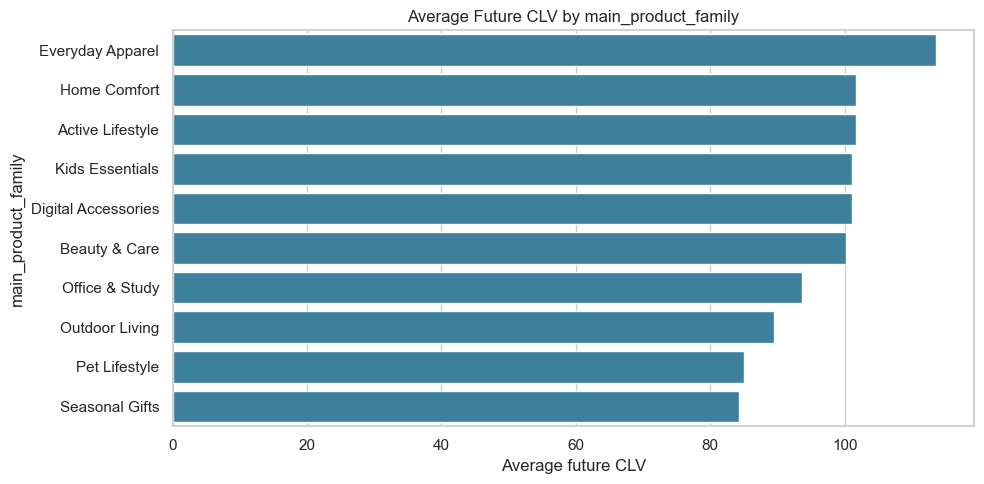

,loyalty_tier,customer_snapshots,avg_future_clv,median_future_clv,avg_return_rate
0,platinum,96790,221.262,166.280,0.087
1,gold,361131,163.954,111.550,0.103
2,silver,602781,102.418,52.720,0.106
3,bronze,501114,58.045,10.820,0.104
4,new,161471,27.388,0.000,0.107


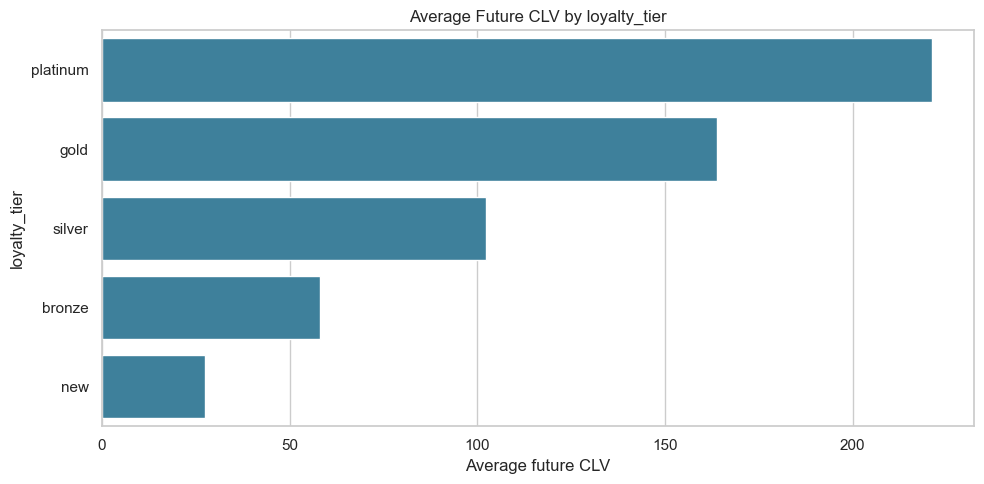

,customer_region,customer_snapshots,avg_future_clv,median_future_clv,avg_return_rate
0,Central Plains,365882,103.358,47.300,0.105
1,Coastal Belt,298955,102.559,45.320,0.103
2,Westport,124719,102.401,42.910,0.103
3,Highland,209712,101.765,43.870,0.104
4,Northlake,156751,101.573,43.110,0.103
5,Southridge,137863,101.565,42.270,0.102
6,Eastvale,246521,101.357,43.990,0.104
7,Metro Core,181151,100.860,43.060,0.105
8,Unknown,1733,57.041,0.000,0.106


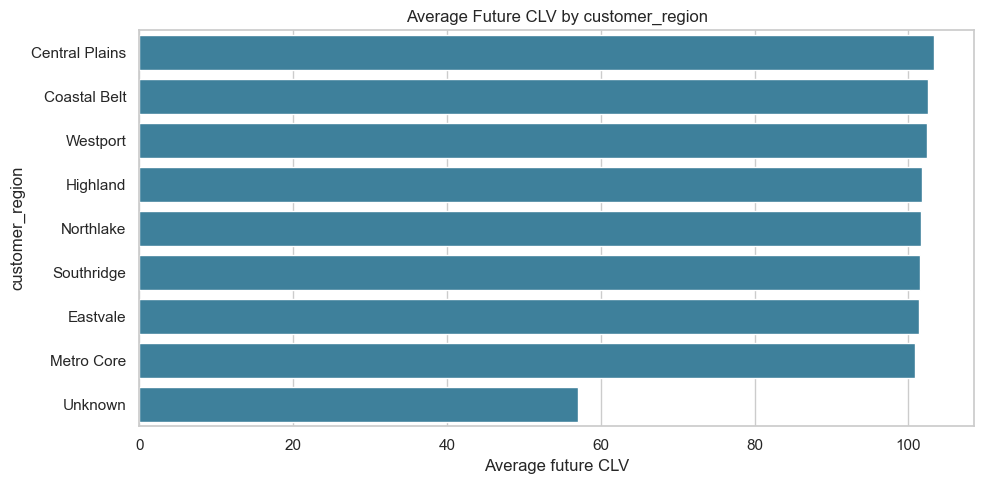

In [11]:
optional_group_cols = ["main_channel", "main_product_family", "loyalty_tier", "customer_region"]

for col in optional_group_cols:
    if col in customer_snapshot_df.columns:
        summary = (
            customer_snapshot_df.groupby(col)
            .agg(
                customer_snapshots=("target_eur", "size"),
                avg_future_clv=("target_eur", "mean"),
                median_future_clv=("target_eur", "median"),
                avg_return_rate=("return_rate", "mean"),
            )
            .sort_values("avg_future_clv", ascending=False)
            .head(15)
            .reset_index()
        )

        display(summary)

        plt.figure(figsize=(10, 5))
        sns.barplot(data=summary, x="avg_future_clv", y=col, color="#2E86AB")
        plt.title(f"Average Future CLV by {col}")
        plt.xlabel("Average future CLV")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()


**Group-level interpretation**

Direct web has the highest average future CLV among channels at about **€109**, while social media has the lowest average future CLV and the highest average return rate in this output. At product-family level, **Everyday Apparel** has the highest average future CLV, but it also carries a higher return rate than most other families.

The loyalty-tier view is especially clear: platinum customers average about **€221** in future CLV, followed by gold at about **€164**. New customers are much lower on average, with a median future CLV of zero.


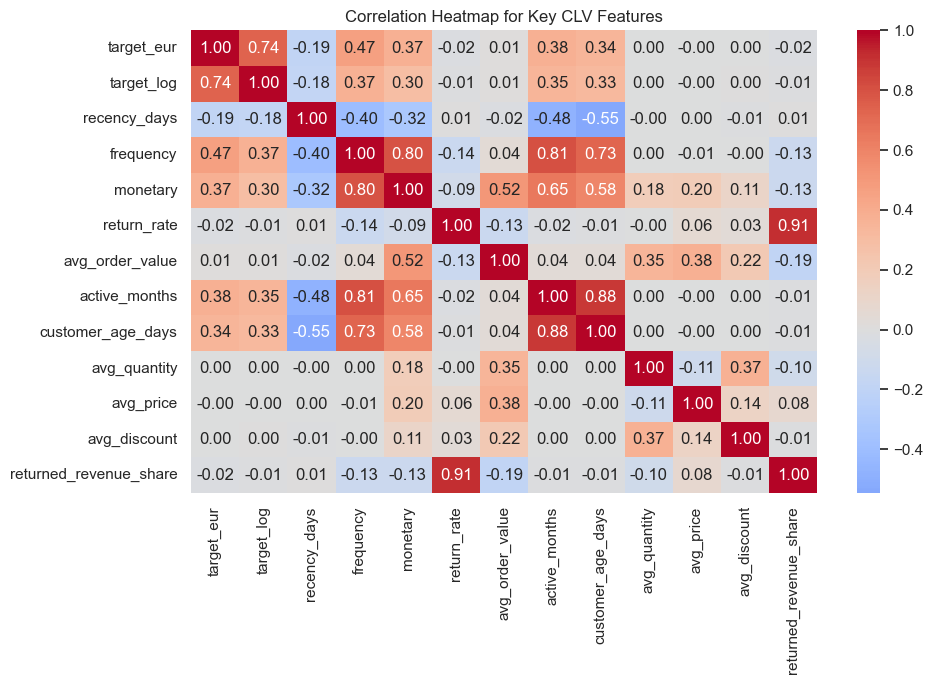

In [12]:
numeric_cols_for_corr = customer_snapshot_df.select_dtypes(include=[np.number]).columns.tolist()
corr_cols = [
    col for col in [
        "target_eur", "target_log", "recency_days", "frequency", "monetary",
        "return_rate", "avg_order_value", "active_months", "customer_age_days",
        "avg_quantity", "avg_price", "avg_discount", "returned_revenue_share"
    ]
    if col in numeric_cols_for_corr
]

if len(corr_cols) >= 3:
    plt.figure(figsize=(10, 7))
    corr = customer_snapshot_df[corr_cols].corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Correlation Heatmap for Key CLV Features")
    plt.tight_layout()
    plt.show()


# 9. Build Final Modeling Dataset

The modeling table keeps one row per customer snapshot. The target is future realized CLV. Columns that describe the prediction window are removed from the feature set so the model only learns from information available at the snapshot date.


In [13]:
target_cols = [
    "future_realized_clv", "future_order_count", "future_valid_orders",
    "future_active_flag", "target_eur", "target_log"
]

date_cols_to_exclude = [
    "snapshot_date", "observation_start", "prediction_end",
    "first_order_date", "last_order_date"
]

id_cols_to_exclude = [SCHEMA["customer_id"]]

exclude_cols = set(target_cols + date_cols_to_exclude + id_cols_to_exclude)

feature_cols = [
    col for col in customer_snapshot_df.columns
    if col not in exclude_cols
]

model_df = customer_snapshot_df.copy()

# Remove columns that are all missing or constant.
usable_feature_cols = []
for col in feature_cols:
    if model_df[col].notna().sum() == 0:
        continue
    if model_df[col].nunique(dropna=True) <= 1:
        continue
    usable_feature_cols.append(col)

feature_cols = usable_feature_cols

print("Modeling dataset shape:", model_df.shape)
print("Number of model features:", len(feature_cols))
print("Target average:", model_df["target_eur"].mean())
print("Target median:", model_df["target_eur"].median())

display(model_df[[SCHEMA["customer_id"], "snapshot_date", "target_eur", "target_log"] + feature_cols[:8]].head())


Modeling dataset shape: (1723287, 57)
Number of model features: 45
Target average: 102.0548584362326
Target median: 44.48


,customer_key,snapshot_date,target_eur,target_log,total_order_lines,returned_order_lines,unique_orders,monetary,avg_line_revenue,active_months,unique_products,unique_product_families
0,CUST-00000001,2024-05-01 00:00:27,57.990,4.077,1,0,1,47.450,47.450,1,1,1
1,CUST-00000004,2024-05-01 00:00:27,326.570,5.792,7,0,2,146.390,20.913,2,7,5
2,CUST-00000007,2024-05-01 00:00:27,0.000,0.000,2,0,1,70.860,35.430,1,2,2
3,CUST-00000008,2024-05-01 00:00:27,0.000,0.000,6,0,2,172.000,28.667,2,6,3
4,CUST-00000009,2024-05-01 00:00:27,0.000,0.000,1,0,1,12.190,12.190,1,1,1


The table contains **1.72M customer snapshots** and **45 usable features**. Average future CLV is about **€102**, while the median is about **€44**, which confirms that the target remains skewed after feature preparation. This is a good reason to keep both log-scale and euro-scale evaluation later.


# 10. Train/Test Time-Based Split

The preferred evaluation design is snapshot-based:

- older snapshots are used for training
- later snapshots are held out for testing

If the available data produces only one snapshot, the target is still time-based, but the evaluation split falls back to a customer-level split after target construction.


In [14]:
def robust_clv_train_test_split(df, schema, test_fraction=0.30, random_state=RANDOM_STATE):
    """Robust train/test split for time-based CLV modeling."""
    customer_col = schema["customer_id"]
    snapshot_dates_sorted = sorted(df["snapshot_date"].dropna().unique())
    n_snapshots = len(snapshot_dates_sorted)

    if n_snapshots == 0:
        raise ValueError(
            "No snapshot dates are available. The window design produced no valid CLV snapshots."
        )

    if n_snapshots >= 3:
        test_size = max(1, int(n_snapshots * test_fraction))
        train_dates = snapshot_dates_sorted[:-test_size]
        test_dates = snapshot_dates_sorted[-test_size:]

        train_df = df[df["snapshot_date"].isin(train_dates)].copy()
        test_df = df[df["snapshot_date"].isin(test_dates)].copy()
        split_strategy = "snapshot_time_split"

    elif n_snapshots == 2:
        train_dates = snapshot_dates_sorted[:1]
        test_dates = snapshot_dates_sorted[1:]

        train_df = df[df["snapshot_date"].isin(train_dates)].copy()
        test_df = df[df["snapshot_date"].isin(test_dates)].copy()
        split_strategy = "snapshot_time_split_two_snapshots"

    else:
        train_dates = snapshot_dates_sorted
        test_dates = snapshot_dates_sorted

        unique_customers = df[customer_col].dropna().unique()
        if len(unique_customers) < 2:
            raise ValueError("Only one snapshot exists and fewer than two customers are available.")

        train_customers, test_customers = train_test_split(
            unique_customers,
            test_size=test_fraction,
            random_state=random_state
        )

        train_df = df[df[customer_col].isin(train_customers)].copy()
        test_df = df[df[customer_col].isin(test_customers)].copy()
        split_strategy = "customer_level_fallback_split"

    if train_df.empty or test_df.empty:
        raise ValueError(
            f"Split failed: train rows={len(train_df)}, test rows={len(test_df)}."
        )

    return train_df, test_df, train_dates, test_dates, split_strategy


train_df, test_df, train_snapshot_dates, test_snapshot_dates, split_strategy = robust_clv_train_test_split(
    model_df,
    SCHEMA
)

snapshot_diagnostic = pd.DataFrame({
    "rows_in_model_df": [len(model_df)],
    "unique_customers": [model_df[SCHEMA["customer_id"]].nunique()],
    "unique_snapshot_dates": [model_df["snapshot_date"].nunique()],
    "first_snapshot_date": [model_df["snapshot_date"].min()],
    "last_snapshot_date": [model_df["snapshot_date"].max()],
    "observation_window_days": [OBSERVATION_DAYS],
    "prediction_window_days": [PREDICTION_DAYS],
    "split_strategy": [split_strategy],
})

display(snapshot_diagnostic)

print("Split strategy:", split_strategy)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

if split_strategy.startswith("snapshot_time_split"):
    print("Train snapshots:", min(train_snapshot_dates), "to", max(train_snapshot_dates))
    print("Test snapshots:", min(test_snapshot_dates), "to", max(test_snapshot_dates))
else:
    print(
        "The CLV target is still built from a future prediction window. "
        "The fallback only affects the evaluation split because there are not enough snapshot dates."
    )


,rows_in_model_df,unique_customers,unique_snapshot_dates,first_snapshot_date,last_snapshot_date,observation_window_days,prediction_window_days,split_strategy
0,1723287,389525,6,2024-05-01 00:00:27,2024-10-01 00:00:27,120,90,snapshot_time_split


Split strategy: snapshot_time_split
Train shape: (1428360, 57)
Test shape: (294927, 57)
Train snapshots: 2024-05-01 00:00:27 to 2024-09-01 00:00:27
Test snapshots: 2024-10-01 00:00:27 to 2024-10-01 00:00:27


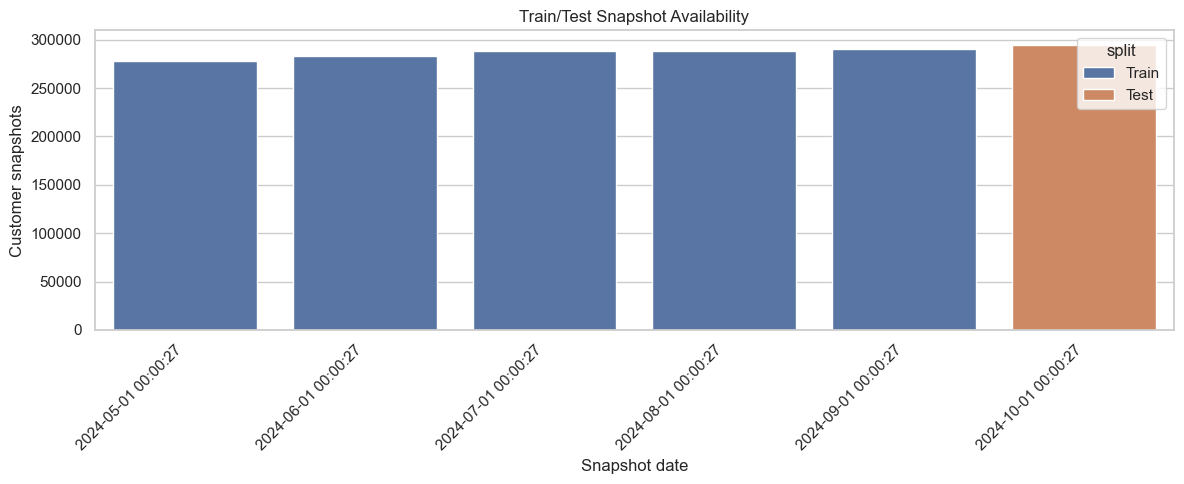

In [15]:
split_plot = (
    model_df.groupby("snapshot_date")
    .agg(customer_snapshots=(SCHEMA["customer_id"], "count"), avg_future_clv=("target_eur", "mean"))
    .reset_index()
)

if split_strategy.startswith("snapshot_time_split"):
    split_plot["split"] = np.where(split_plot["snapshot_date"].isin(test_snapshot_dates), "Test", "Train")
else:
    split_plot["split"] = "Single snapshot — customer-level split"

plt.figure(figsize=(12, 5))
sns.barplot(data=split_plot, x="snapshot_date", y="customer_snapshots", hue="split")
plt.title("Train/Test Snapshot Availability")
plt.xlabel("Snapshot date")
plt.ylabel("Customer snapshots")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


The model uses six snapshot dates from May to October 2024. Older snapshots are used for training and the latest snapshot is for testing.


# 11. Baseline CLV Models

Baselines are kept in the comparison because a CLV model should first prove that it improves over simple customer-value rules. The baseline models predict the average or median future CLV from the training set.


In [16]:
X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

y_train_log = train_df["target_log"].copy()
y_test_log = test_df["target_log"].copy()

y_train_eur = train_df["target_eur"].copy()
y_test_eur = test_df["target_eur"].copy()

baseline_models = {
    "Mean Baseline": DummyRegressor(strategy="mean"),
    "Median Baseline": DummyRegressor(strategy="median"),
}

print("Train rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])
print("Feature columns:", len(feature_cols))


Train rows: 1428360
Test rows: 294927
Feature columns: 45


# 12. CLV Models

The model set combines simple and nonlinear approaches:

- **Ridge Regression** as a linear reference model
- **Random Forest** and **ExtraTrees** for nonlinear customer behavior
- **HistGradientBoosting** as another tree-based benchmark
- optional XGBoost and LightGBM models when available

Tree-based models can capture nonlinear patterns from RFM-R, purchase, return, product, channel, timing, and loyalty features. A complex model is useful only if it improves prediction or ranking quality over simpler alternatives.

The models train on `log1p(future_realized_clv)` and are evaluated in both log scale and euros.


In [17]:
def make_one_hot_encoder():
    """Create a OneHotEncoder compatible with older and newer scikit-learn versions."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def detect_feature_types(df):
    """Detect numeric and categorical features, including string dtype."""
    numeric_features = df.select_dtypes(include=[np.number, "bool"]).columns.tolist()
    categorical_features = df.select_dtypes(include=["object", "category", "string"]).columns.tolist()
    return numeric_features, categorical_features


def build_preprocessor(X, scale_numeric=False):
    """Build a reusable preprocessing pipeline."""
    numeric_features, categorical_features = detect_feature_types(X)

    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    transformers = []

    if numeric_features:
        transformers.append(("num", Pipeline(steps=numeric_steps), numeric_features))

    if categorical_features:
        transformers.append((
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
                ("onehot", make_one_hot_encoder()),
            ]),
            categorical_features,
        ))

    return ColumnTransformer(transformers=transformers, remainder="drop")


def build_model_pipeline(model, X, scale_numeric=False):
    """Build a complete model pipeline with its own preprocessing object."""
    return Pipeline(steps=[
        ("preprocessor", build_preprocessor(X, scale_numeric=scale_numeric)),
        ("model", model),
    ])


models = {
    "Ridge Regression": build_model_pipeline(Ridge(alpha=1.0), X_train, scale_numeric=True),
    "Random Forest": build_model_pipeline(
        RandomForestRegressor(
            n_estimators=250,
            max_depth=None,
            min_samples_leaf=3,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        X_train,
        scale_numeric=False,
    ),
    "ExtraTrees": build_model_pipeline(
        ExtraTreesRegressor(
            n_estimators=250,
            max_depth=None,
            min_samples_leaf=3,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        X_train,
        scale_numeric=False,
    ),
    "HistGradientBoosting": build_model_pipeline(
        HistGradientBoostingRegressor(
            max_iter=250,
            learning_rate=0.05,
            max_leaf_nodes=31,
            l2_regularization=0.1,
            random_state=RANDOM_STATE,
        ),
        X_train,
        scale_numeric=False,
    ),
}

if XGBOOST_AVAILABLE:
    models["XGBoost"] = build_model_pipeline(
        XGBRegressor(
            n_estimators=400,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        X_train,
        scale_numeric=False,
    )

if LIGHTGBM_AVAILABLE:
    models["LightGBM"] = build_model_pipeline(
        LGBMRegressor(
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        X_train,
        scale_numeric=False,
    )

print("Models to train:", list(models.keys()))


Models to train: ['Ridge Regression', 'Random Forest', 'ExtraTrees', 'HistGradientBoosting']


# 13. Hyperparameter Tuning


In [18]:
def get_time_series_cv(n_rows, max_splits=3):
    """Create a safe TimeSeriesSplit object."""
    n_splits = min(max_splits, max(2, n_rows // 4))
    return TimeSeriesSplit(n_splits=n_splits)


def sample_for_tuning(X, y, max_rows=TUNING_SAMPLE_SIZE):
    """Use a capped sample for lightweight tuning."""
    if len(X) <= max_rows:
        return X, y

    sample_idx = X.sample(max_rows, random_state=RANDOM_STATE).index
    return X.loc[sample_idx], y.loc[sample_idx]


X_tune, y_tune = sample_for_tuning(X_train, y_train_log)

if len(X_tune) >= 1_000:
    hgb_param_grid = {
        "model__max_iter": [150, 250, 350],
        "model__learning_rate": [0.03, 0.05, 0.08],
        "model__max_leaf_nodes": [15, 31, 63],
        "model__l2_regularization": [0.0, 0.1, 0.5],
    }

    hgb_search = RandomizedSearchCV(
        estimator=build_model_pipeline(
            HistGradientBoostingRegressor(random_state=RANDOM_STATE),
            X_tune,
            scale_numeric=False,
        ),
        param_distributions=hgb_param_grid,
        n_iter=8,
        scoring="neg_mean_squared_error",
        cv=get_time_series_cv(len(X_tune)),
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
    )

    hgb_search.fit(X_tune, y_tune)
    models["Tuned HistGradientBoosting"] = hgb_search.best_estimator_

    print("Best HistGradientBoosting parameters:")
    print(hgb_search.best_params_)
else:
    print("Tuning skipped because the training sample is too small for stable cross-validation.")


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best HistGradientBoosting parameters:
{'model__max_leaf_nodes': 15, 'model__max_iter': 250, 'model__learning_rate': 0.03, 'model__l2_regularization': 0.1}


# 14. Model Evaluation on Log Scale and Euro Scale

Model quality is reviewed in two views:

- **Log scale:** useful because CLV is skewed and many customers have low or zero future value.
- **Euro scale:** easier to interpret for customer prioritization and business planning.

Metrics:

- **MAE:** average absolute error
- **RMSE:** penalizes larger misses more strongly
- **Median Absolute Error:** typical absolute miss
- **R²:** variation explained
- **MAPE:** percentage error, calculated only where actual value is nonzero

Exact euro prediction is difficult in CLV. Ranking quality is often just as important as average error because teams usually use CLV to prioritize groups of customers.


In [19]:
def rmse_score(y_true, y_pred):
    """RMSE compatible with older scikit-learn versions."""
    return mean_squared_error(y_true, y_pred) ** 0.5


def safe_mape(y_true, y_pred):
    """Calculate MAPE safely by excluding zero actual values."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0

    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))


def regression_metrics_log(y_true_log, y_pred_log):
    return {
        "MAE_log": mean_absolute_error(y_true_log, y_pred_log),
        "RMSE_log": rmse_score(y_true_log, y_pred_log),
        "R2_log": r2_score(y_true_log, y_pred_log),
    }


def regression_metrics_eur(y_true_eur, y_pred_eur):
    return {
        "MAE_eur": mean_absolute_error(y_true_eur, y_pred_eur),
        "RMSE_eur": rmse_score(y_true_eur, y_pred_eur),
        "MedianAE_eur": median_absolute_error(y_true_eur, y_pred_eur),
        "MAPE_eur": safe_mape(y_true_eur, y_pred_eur),
        "R2_eur": r2_score(y_true_eur, y_pred_eur),
    }


evaluation_rows = []
prediction_store = {}
fitted_models = {}

# Baselines
for name, model in baseline_models.items():
    model.fit(X_train, y_train_log)

    pred_log = model.predict(X_test)
    pred_eur = np.expm1(pred_log).clip(min=0)

    evaluation_rows.append({
        "model": name,
        **regression_metrics_log(y_test_log, pred_log),
        **regression_metrics_eur(y_test_eur, pred_eur),
    })

    prediction_store[name] = {"pred_log": pred_log, "pred_eur": pred_eur}
    fitted_models[name] = model

# ML models
for name, model in models.items():
    print("Training:", name)
    model.fit(X_train, y_train_log)

    pred_log = model.predict(X_test)
    pred_eur = np.expm1(pred_log).clip(min=0)

    evaluation_rows.append({
        "model": name,
        **regression_metrics_log(y_test_log, pred_log),
        **regression_metrics_eur(y_test_eur, pred_eur),
    })

    prediction_store[name] = {"pred_log": pred_log, "pred_eur": pred_eur}
    fitted_models[name] = model

model_comparison = (
    pd.DataFrame(evaluation_rows)
    .sort_values("RMSE_eur")
    .reset_index(drop=True)
)

display(model_comparison)


Training: Ridge Regression
Training: Random Forest
Training: ExtraTrees
Training: HistGradientBoosting
Training: Tuned HistGradientBoosting


,model,MAE_log,RMSE_log,R2_log,MAE_eur,RMSE_eur,MedianAE_eur,MAPE_eur,R2_eur
0,ExtraTrees,1.577,1.874,0.328,88.913,149.977,40.846,0.792,0.096
1,Random Forest,1.638,1.912,0.300,90.958,152.709,41.029,0.793,0.063
2,HistGradientBoosting,1.712,2.002,0.233,91.895,152.944,42.745,0.814,0.060
3,Tuned HistGradientBoosting,1.715,2.003,0.232,92.089,153.352,42.622,0.812,0.055
4,Ridge Regression,1.727,2.009,0.228,93.627,160.551,42.791,0.829,-0.035
5,Median Baseline,1.918,2.329,-0.038,105.679,175.349,41.320,0.790,-0.235
6,Mean Baseline,2.114,2.317,-0.027,110.999,186.921,42.741,0.775,-0.404


### Reading the Model Comparison

The model table is sorted by euro RMSE, but CLV should not be judged only by exact euro prediction.

A useful CLV model should also rank customers reasonably well. Customers with higher predicted CLV should, on average, generate higher actual future CLV.


In [20]:
best_model_name = model_comparison.iloc[0]["model"]
best_model = fitted_models[best_model_name]
best_prediction = prediction_store[best_model_name]

print("Best model:", best_model_name)
print(f"Average error per customer snapshot (MAE): {model_comparison.iloc[0]['MAE_eur']:,.2f}")
print(f"RMSE: {model_comparison.iloc[0]['RMSE_eur']:,.2f}")
print(f"R² on euro scale: {model_comparison.iloc[0]['R2_eur']:.3f}")


Best model: ExtraTrees
Average error per customer snapshot (MAE): 88.91
RMSE: 149.98
R² on euro scale: 0.096


ExtraTrees performs best in this run, with an MAE of about **€88.91** and RMSE of about **€149.98** per customer snapshot. It improves over the median baseline RMSE of about **€175.35** and the mean baseline RMSE of about **€186.92**. The euro-scale R² is modest at **0.096**, which is common in customer-value prediction. Individual future purchases are noisy.


# 15. Prediction Error and Ranking Analysis

CLV is often used for prioritization, so ranking quality matters.

This section checks two things:

1. how close the predictions are to actual future CLV
2. whether higher predicted groups contain higher actual future value

The second view is especially useful for CRM and retention planning.


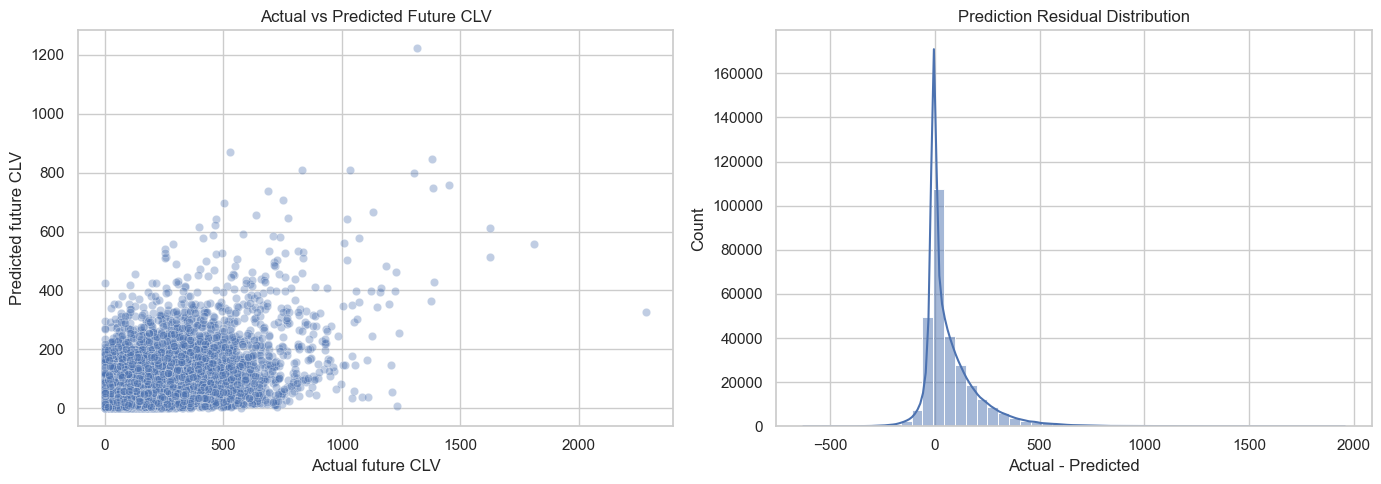

,customer_key,snapshot_date,target_eur,target_log,predicted_clv_log,predicted_clv_euros,residual_eur
1428360,CUST-00000002,2024-10-01 00:00:27,0.000,0.000,0.450,0.569,-0.569
1428361,CUST-00000003,2024-10-01 00:00:27,0.000,0.000,2.509,11.289,-11.289
1428362,CUST-00000004,2024-10-01 00:00:27,86.910,4.476,5.037,153.003,-66.093
1428363,CUST-00000009,2024-10-01 00:00:27,21.560,3.116,1.009,1.743,19.817
1428364,CUST-00000014,2024-10-01 00:00:27,31.990,3.496,2.913,17.416,14.574


In [21]:
evaluation_df = test_df[[SCHEMA["customer_id"], "snapshot_date", "target_eur", "target_log"]].copy()
evaluation_df["predicted_clv_log"] = best_prediction["pred_log"]
evaluation_df["predicted_clv_euros"] = best_prediction["pred_eur"]
evaluation_df["residual_eur"] = evaluation_df["target_eur"] - evaluation_df["predicted_clv_euros"]

plot_sample = evaluation_df.sample(min(20_000, len(evaluation_df)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=plot_sample,
    x="target_eur",
    y="predicted_clv_euros",
    alpha=0.35,
    ax=axes[0],
)
axes[0].set_title("Actual vs Predicted Future CLV")
axes[0].set_xlabel("Actual future CLV")
axes[0].set_ylabel("Predicted future CLV")

sns.histplot(evaluation_df["residual_eur"], bins=50, kde=True, ax=axes[1])
axes[1].set_title("Prediction Residual Distribution")
axes[1].set_xlabel("Actual - Predicted")

plt.tight_layout()
plt.show()

display(evaluation_df.head())


**Interpretation**

The scatter and residual views show the usual CLV challenge: many customers have low or zero future value, while a smaller group has much higher actual value.


,predicted_clv_decile,customer_snapshots,avg_predicted_clv,avg_actual_clv,total_actual_clv
0,D1,29493,1.924,19.433,"573,147.270"
1,D2,29493,4.407,33.334,"983,125.880"
2,D3,29492,7.234,49.798,"1,468,657.290"
3,D4,29493,11.398,70.390,"2,076,011.070"
4,D5,29493,17.350,88.280,"2,603,642.580"
5,D6,29492,25.448,106.342,"3,136,229.320"
6,D7,29493,36.924,128.415,"3,787,338.400"
7,D8,29492,55.528,157.708,"4,651,114.960"
8,D9,29493,91.381,203.357,"5,997,594.620"
9,D10,29493,211.641,321.204,"9,473,270.510"


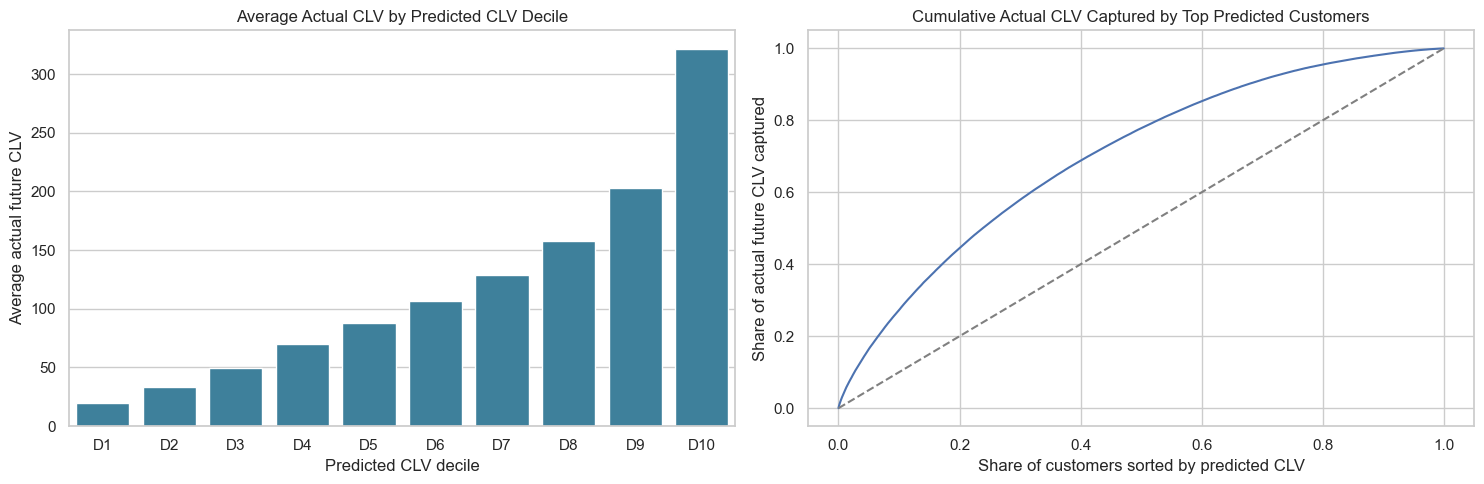

In [22]:
def assign_deciles(series, labels=None):
    """Assign deciles robustly using rank to handle ties."""
    if labels is None:
        labels = [f"D{i}" for i in range(1, 11)]

    try:
        return pd.qcut(series.rank(method="first"), q=10, labels=labels)
    except Exception:
        return pd.cut(series.rank(method="first"), bins=10, labels=labels)


evaluation_df["predicted_clv_decile"] = assign_deciles(
    evaluation_df["predicted_clv_euros"],
    labels=[f"D{i}" for i in range(1, 11)]
)

decile_summary = (
    evaluation_df.groupby("predicted_clv_decile", observed=False)
    .agg(
        customer_snapshots=(SCHEMA["customer_id"], "count"),
        avg_predicted_clv=("predicted_clv_euros", "mean"),
        avg_actual_clv=("target_eur", "mean"),
        total_actual_clv=("target_eur", "sum"),
    )
    .reset_index()
)

display(decile_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(
    data=decile_summary,
    x="predicted_clv_decile",
    y="avg_actual_clv",
    ax=axes[0],
    color="#2E86AB",
)
axes[0].set_title("Average Actual CLV by Predicted CLV Decile")
axes[0].set_xlabel("Predicted CLV decile")
axes[0].set_ylabel("Average actual future CLV")

ranked = evaluation_df.sort_values("predicted_clv_euros", ascending=False).copy()
ranked["customer_rank_pct"] = np.arange(1, len(ranked) + 1) / len(ranked)
ranked["cumulative_actual_clv_share"] = ranked["target_eur"].cumsum() / ranked["target_eur"].sum()

sns.lineplot(
    data=ranked,
    x="customer_rank_pct",
    y="cumulative_actual_clv_share",
    ax=axes[1],
)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("Cumulative Actual CLV Captured by Top Predicted Customers")
axes[1].set_xlabel("Share of customers sorted by predicted CLV")
axes[1].set_ylabel("Share of actual future CLV captured")

plt.tight_layout()
plt.show()


**Ranking interpretation**

The decile view is stronger than the customer-level scatter plot for business use. The top predicted decile has an average actual future CLV of about **€321**, compared with about **€19** in the bottom decile.

The top predicted decile captures about **27%** of actual future CLV in the test set, and the top three predicted deciles capture about **58%**. That makes the model useful for customer prioritization, even though individual euro-level predictions are not perfect.


# 16. Feature Importance and CLV Drivers

Let's review which features contribute most to predicted future CLV. Two views are used:

- model-specific importance for tree-based models
- permutation importance on a sample of the test data

They help explain which customer signals the model relies on most.


,feature,importance
70,cat__loyalty_tier_bronze,0.043
72,cat__loyalty_tier_new,0.038
9,num__unique_carriers,0.033
37,num__carrier_count,0.031
14,num__avg_delivery_delay,0.029
13,num__avg_dispatch_delay,0.028
12,num__avg_discount,0.028
8,num__unique_channels,0.025
11,num__avg_price,0.025
10,num__avg_quantity,0.021


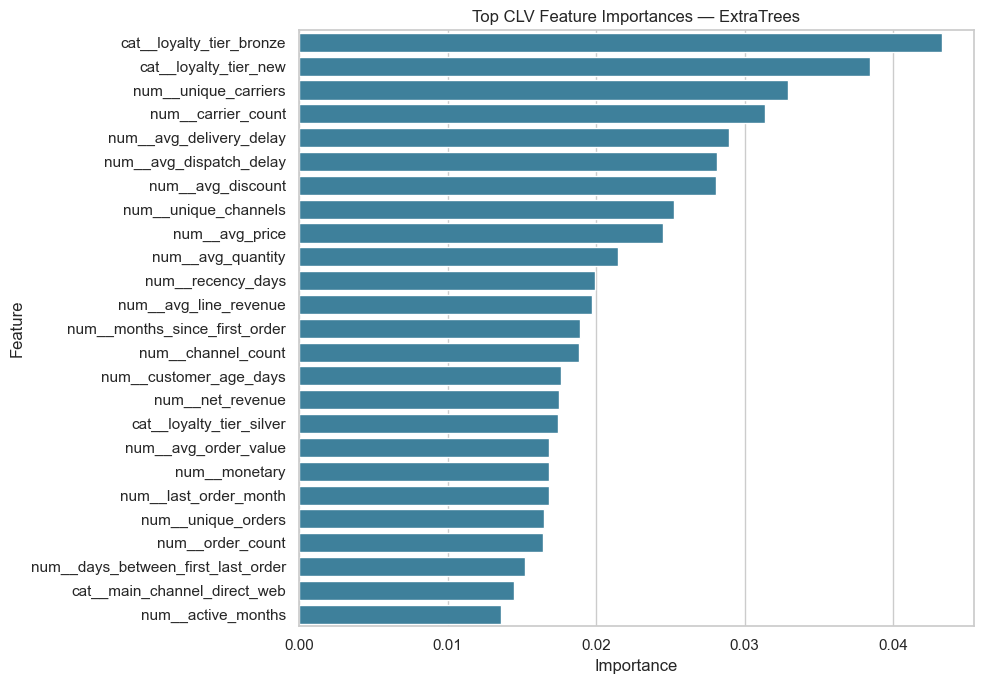

In [23]:
def get_feature_names_from_pipeline(pipeline):
    """Return transformed feature names from a fitted pipeline when available."""
    try:
        return pipeline.named_steps["preprocessor"].get_feature_names_out()
    except Exception:
        return np.array(feature_cols)


importance_df = None

if hasattr(best_model, "named_steps") and hasattr(best_model.named_steps["model"], "coef_"):
    feature_names = get_feature_names_from_pipeline(best_model)
    coefficients = best_model.named_steps["model"].coef_

    importance_df = (
        pd.DataFrame({"feature": feature_names, "coefficient": coefficients})
        .assign(abs_coefficient=lambda x: x["coefficient"].abs())
        .sort_values("abs_coefficient", ascending=False)
        .head(25)
    )

    display(importance_df)

    plt.figure(figsize=(10, 7))
    sns.barplot(data=importance_df, x="coefficient", y="feature", color="#2E86AB")
    plt.title(f"Top CLV Coefficients — {best_model_name}")
    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

elif hasattr(best_model, "named_steps") and hasattr(best_model.named_steps["model"], "feature_importances_"):
    feature_names = get_feature_names_from_pipeline(best_model)
    importances = best_model.named_steps["model"].feature_importances_

    importance_df = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(25)
    )

    display(importance_df)

    plt.figure(figsize=(10, 7))
    sns.barplot(data=importance_df, x="importance", y="feature", color="#2E86AB")
    plt.title(f"Top CLV Feature Importances — {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

else:
    print("The selected model does not expose direct coefficients or feature importances.")


,feature,importance_mean,importance_std
39,loyalty_tier,1.397,0.156
40,customer_region,0.303,0.009
34,last_order_month,0.302,0.016
37,main_product_family,0.277,0.040
38,main_carrier,0.245,0.016
35,last_order_weekday,0.217,0.006
36,main_channel,0.209,0.000
2,unique_orders,0.133,0.001
19,order_count,0.131,0.003
13,avg_dispatch_delay,0.070,0.014


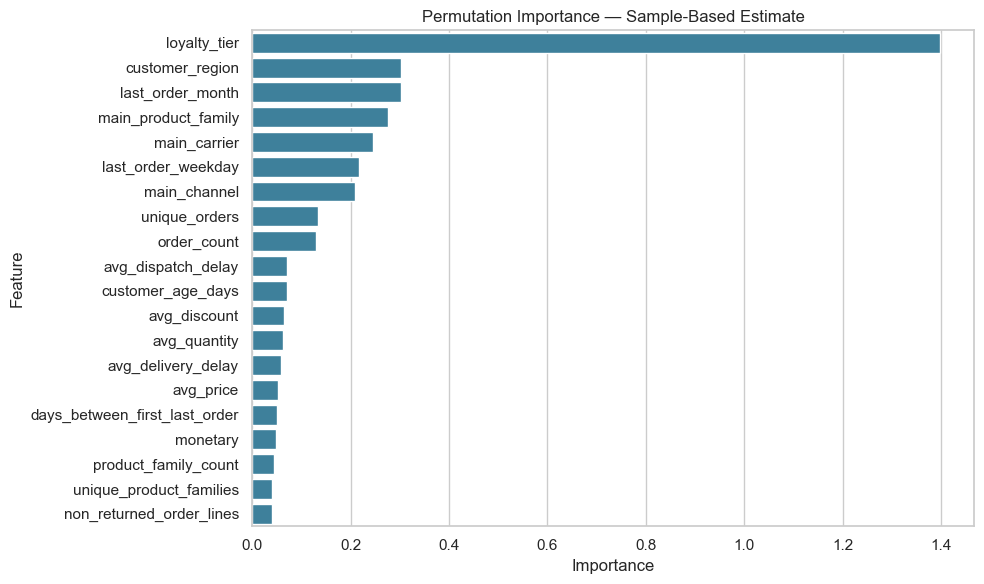

In [24]:
if len(X_test) > 0:
    sample_size = min(PERMUTATION_SAMPLE_SIZE, len(X_test))
    X_perm = X_test.sample(sample_size, random_state=RANDOM_STATE)
    y_perm = y_test_log.loc[X_perm.index]

    try:
        perm_result = permutation_importance(
            best_model,
            X_perm,
            y_perm,
            n_repeats=2,
            random_state=RANDOM_STATE,
            n_jobs=1,
            scoring="neg_mean_squared_error",
        )

        permutation_df = (
            pd.DataFrame({
                "feature": X_perm.columns,
                "importance_mean": perm_result.importances_mean,
                "importance_std": perm_result.importances_std,
            })
            .sort_values("importance_mean", ascending=False)
            .head(20)
        )

        display(permutation_df)

        plt.figure(figsize=(10, 6))
        sns.barplot(data=permutation_df, x="importance_mean", y="feature", color="#2E86AB")
        plt.title("Permutation Importance — Sample-Based Estimate")
        plt.xlabel("Importance")
        plt.ylabel("Feature")
        plt.tight_layout()
        plt.show()

    except Exception as exc:
        print("Permutation importance skipped:", exc)


The importance results point to customer maturity and behavior context as major CLV signals. Loyalty tier is the strongest grouped driver, followed by region, recent order timing, product family, carrier, channel, and order activity.


# 17. Customer Value Scoring and CLV Bands

The selected model is used to score current eligible customers. The scoring date is the day after the latest order timestamp in the dataset. Each customer receives a predicted future CLV and a CLV band, which makes the output easier to discuss than a long list of raw predictions.

CLV bands turn model scores into customer groups that are easier to discuss:

- **Very High Value:** strongest group for loyalty and retention planning
- **High Value:** customers worth reviewing for retention and cross-sell opportunities
- **Medium Value:** moderate expected value
- **Low Value:** lower expected value within the selected prediction window

The business-value analysis separates high-value low-return customers from high-value customers with higher return behavior. That makes the output more useful than a simple “top customers” list.


In [25]:
scoring_date = analysis_df[SCHEMA["order_date"]].max() + pd.Timedelta(days=1)

current_features = build_customer_clv_snapshot(
    analysis_df,
    SCHEMA,
    snapshot_date=scoring_date,
    observation_days=OBSERVATION_DAYS,
    prediction_days=PREDICTION_DAYS,
)

for col in feature_cols:
    if col not in current_features.columns:
        current_features[col] = np.nan

X_current = current_features[feature_cols].copy()

current_pred_log = best_model.predict(X_current)
current_pred_eur = np.expm1(current_pred_log).clip(min=0)

customer_clv_scores = current_features.copy()
customer_clv_scores["scoring_date"] = scoring_date
customer_clv_scores["predicted_future_clv_log"] = current_pred_log
customer_clv_scores["predicted_future_clv_euros"] = current_pred_eur

customer_clv_scores["clv_band"] = pd.qcut(
    customer_clv_scores["predicted_future_clv_euros"].rank(method="first"),
    q=4,
    labels=["Low Value", "Medium Value", "High Value", "Very High Value"],
)

score_columns = [
    SCHEMA["customer_id"], "scoring_date", "predicted_future_clv_log", "predicted_future_clv_euros",
    "clv_band", "recency_days", "frequency", "monetary", "return_rate",
    "full_return_customer_flag", "main_channel", "main_product_family",
    "loyalty_tier", "customer_region",
]
score_columns = [col for col in score_columns if col in customer_clv_scores.columns]

display(customer_clv_scores[score_columns].head())


,customer_key,scoring_date,predicted_future_clv_log,predicted_future_clv_euros,clv_band,recency_days,frequency,monetary,return_rate,full_return_customer_flag,main_channel,main_product_family,loyalty_tier,customer_region
0,CUST-00000004,2025-01-01 23:59:32,4.736,112.951,Very High Value,44,4,162.090,0.000,0,direct_web,Active Lifestyle,gold,Central Plains
1,CUST-00000005,2025-01-01 23:59:32,1.839,5.288,Low Value,34,1,107.870,0.250,0,email_campaign,Beauty & Care,bronze,Central Plains
2,CUST-00000008,2025-01-01 23:59:32,5.112,165.076,Very High Value,6,5,359.940,0.091,0,affiliate_partner,Home Comfort,gold,Southridge
3,CUST-00000009,2025-01-01 23:59:32,1.079,1.941,Low Value,16,1,21.560,0.000,0,marketplace,Kids Essentials,new,Coastal Belt
4,CUST-00000011,2025-01-01 23:59:32,3.226,24.190,Medium Value,30,2,52.740,0.333,0,paid_search,Home Comfort,silver,Central Plains


The customer-level table includes the predicted future CLV, CLV band, recent activity, frequency, monetary value, return behavior, and customer context. The value of this table is not only the prediction itself. It also gives enough supporting fields to check whether a high-value customer is a clean value opportunity or a return-risk case.


,clv_band,customers,total_predicted_clv,avg_predicted_clv,avg_recency,avg_frequency,avg_monetary,avg_return_rate
0,Low Value,83259,"444,538.492",5.339,51.744,1.120,70.747,0.125
1,Medium Value,83259,"1,336,881.951",16.057,44.490,1.508,98.017,0.139
2,High Value,83258,"3,275,451.553",39.341,34.683,2.327,149.614,0.130
3,Very High Value,83259,"13,869,635.195",166.584,18.798,5.457,347.113,0.111


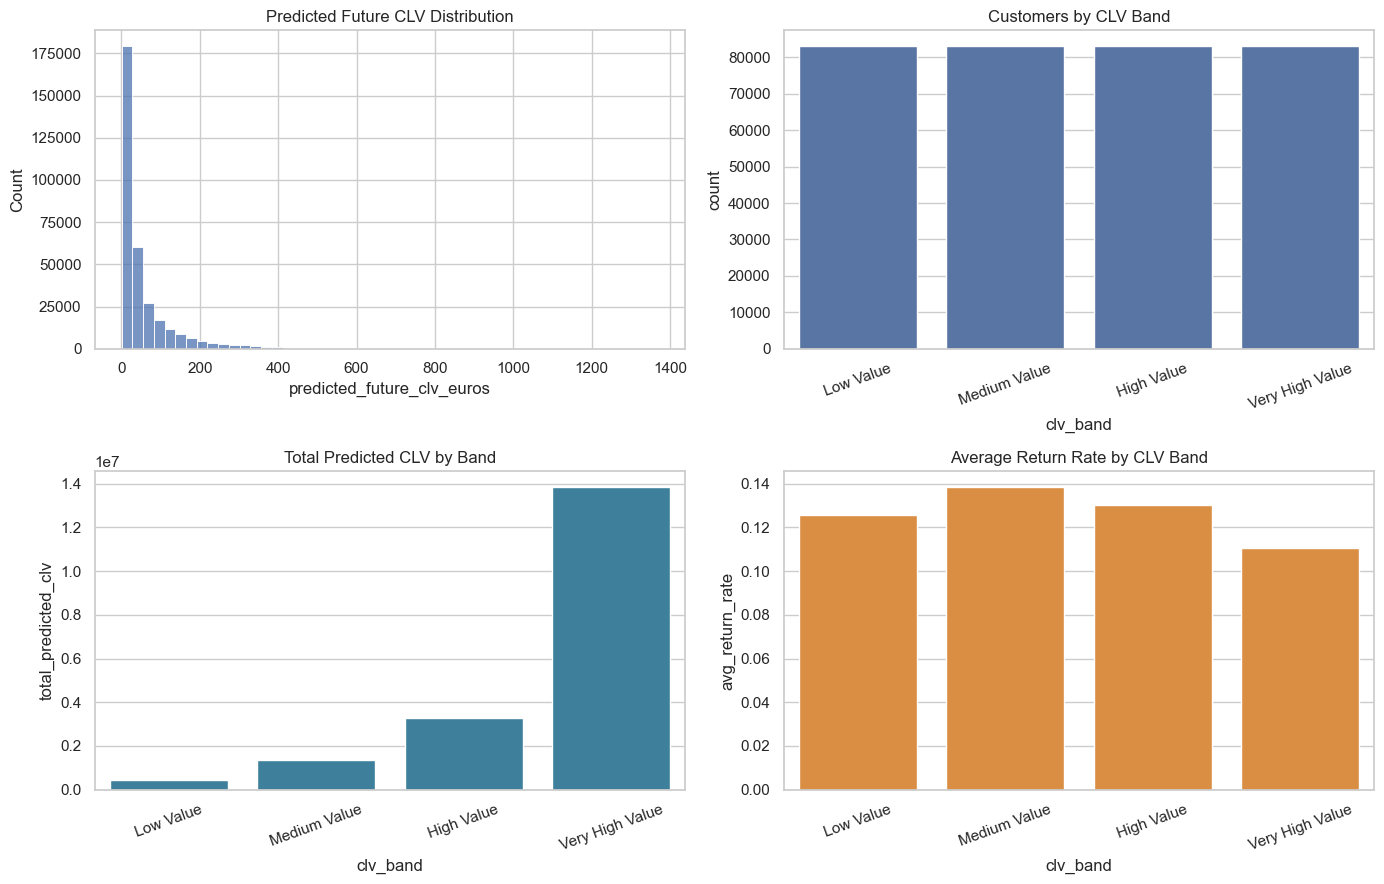

In [26]:
clv_band_summary = (
    customer_clv_scores.groupby("clv_band", observed=False)
    .agg(
        customers=(SCHEMA["customer_id"], "nunique"),
        total_predicted_clv=("predicted_future_clv_euros", "sum"),
        avg_predicted_clv=("predicted_future_clv_euros", "mean"),
        avg_recency=("recency_days", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
        avg_return_rate=("return_rate", "mean"),
    )
    .reset_index()
)

display(clv_band_summary)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.histplot(customer_clv_scores["predicted_future_clv_euros"], bins=50, ax=axes[0, 0])
axes[0, 0].set_title("Predicted Future CLV Distribution")

sns.countplot(data=customer_clv_scores, x="clv_band", ax=axes[0, 1])
axes[0, 1].set_title("Customers by CLV Band")
axes[0, 1].tick_params(axis="x", rotation=20)

sns.barplot(data=clv_band_summary, x="clv_band", y="total_predicted_clv", ax=axes[1, 0], color="#2E86AB")
axes[1, 0].set_title("Total Predicted CLV by Band")
axes[1, 0].tick_params(axis="x", rotation=20)

sns.barplot(data=clv_band_summary, x="clv_band", y="avg_return_rate", ax=axes[1, 1], color="#F28E2B")
axes[1, 1].set_title("Average Return Rate by CLV Band")
axes[1, 1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


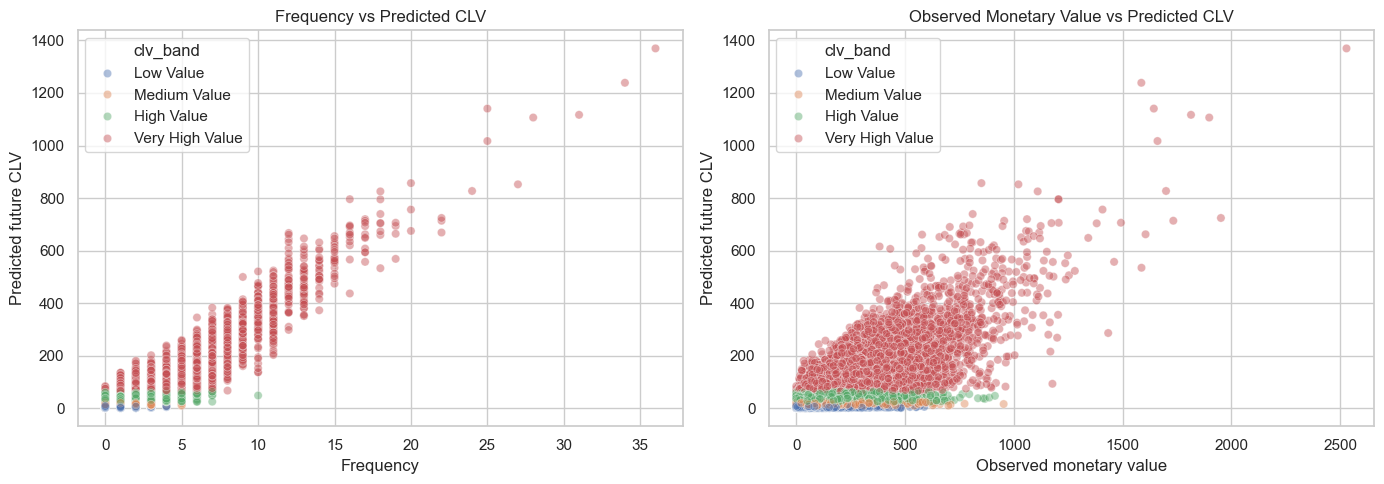

In [27]:
scatter_sample = customer_clv_scores.sample(min(20_000, len(customer_clv_scores)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=scatter_sample,
    x="frequency",
    y="predicted_future_clv_euros",
    hue="clv_band",
    alpha=0.45,
    ax=axes[0],
)
axes[0].set_title("Frequency vs Predicted CLV")
axes[0].set_xlabel("Frequency")
axes[0].set_ylabel("Predicted future CLV")

sns.scatterplot(
    data=scatter_sample,
    x="monetary",
    y="predicted_future_clv_euros",
    hue="clv_band",
    alpha=0.45,
    ax=axes[1],
)
axes[1].set_title("Observed Monetary Value vs Predicted CLV")
axes[1].set_xlabel("Observed monetary value")
axes[1].set_ylabel("Predicted future CLV")

plt.tight_layout()
plt.show()


**Interpretation**

The CLV bands split customers into four equally sized groups, but the predicted value is highly concentrated. The **Very High Value** band contains about **83K customers** and roughly **€13.87M** in predicted future CLV, about **73%** of the total predicted value in the scoring output.

This band also has the strongest customer behavior profile: lower recency, higher frequency, higher monetary value, and the lowest average return rate among the bands. The Medium Value band has the highest average return rate in this output, so value quality still needs to be checked outside the top band.


# 18. Business Value Analysis

Now we should turn customer CLV scores into practical customer views. The goal is not to create rigid rules. It is to separate customer groups that may need different treatment: loyalty attention, retention review, reactivation, or return-behavior checks.


In [28]:
top_predicted_clv = (
    customer_clv_scores[score_columns]
    .sort_values("predicted_future_clv_euros", ascending=False)
    .head(20)
)

high_value_threshold = customer_clv_scores["predicted_future_clv_euros"].quantile(0.90)
high_return_threshold = customer_clv_scores["return_rate"].quantile(0.75)

high_value_high_return = customer_clv_scores[
    (customer_clv_scores["predicted_future_clv_euros"] >= high_value_threshold) &
    (customer_clv_scores["return_rate"] >= high_return_threshold)
].copy()

high_value_low_return = customer_clv_scores[
    (customer_clv_scores["predicted_future_clv_euros"] >= high_value_threshold) &
    (customer_clv_scores["return_rate"] <= customer_clv_scores["return_rate"].quantile(0.25))
].copy()

print("Top predicted CLV customers:")
display(top_predicted_clv)

print("High-value customers with higher return behavior:")
display(high_value_high_return[score_columns].sort_values("predicted_future_clv_euros", ascending=False).head(20))

print("High-value customers with lower return behavior:")
display(high_value_low_return[score_columns].sort_values("predicted_future_clv_euros", ascending=False).head(20))


Top predicted CLV customers:


,customer_key,scoring_date,predicted_future_clv_log,predicted_future_clv_euros,clv_band,recency_days,frequency,monetary,return_rate,full_return_customer_flag,main_channel,main_product_family,loyalty_tier,customer_region
240136,CUST-00361874,2025-01-01 23:59:32,7.223,"1,369.683",Very High Value,1,36,"2,528.670",0.091,0,social_media,Beauty & Care,platinum,Coastal Belt
302593,CUST-00455662,2025-01-01 23:59:32,7.208,"1,348.669",Very High Value,1,30,"2,352.690",0.095,0,organic_search,Home Comfort,gold,Westport
61589,CUST-00093172,2025-01-01 23:59:32,7.195,"1,331.792",Very High Value,1,29,"1,665.410",0.071,0,social_media,Everyday Apparel,platinum,Metro Core
119955,CUST-00180987,2025-01-01 23:59:32,7.172,"1,301.702",Very High Value,4,31,"2,077.040",0.077,0,paid_search,Kids Essentials,platinum,Highland
73391,CUST-00110951,2025-01-01 23:59:32,7.166,"1,294.110",Very High Value,2,29,"1,998.050",0.182,0,organic_search,Everyday Apparel,gold,Southridge
123850,CUST-00186836,2025-01-01 23:59:32,7.166,"1,293.334",Very High Value,2,31,"1,635.490",0.074,0,organic_search,Active Lifestyle,gold,Westport
206142,CUST-00310614,2025-01-01 23:59:32,7.160,"1,285.751",Very High Value,10,27,"2,346.160",0.113,0,marketplace,Home Comfort,platinum,Eastvale
37389,CUST-00056552,2025-01-01 23:59:32,7.154,"1,278.690",Very High Value,4,33,"1,920.270",0.154,0,direct_web,Kids Essentials,gold,Westport
264441,CUST-00398373,2025-01-01 23:59:32,7.154,"1,278.673",Very High Value,4,26,"1,874.020",0.056,0,organic_search,Kids Essentials,gold,Highland
279185,CUST-00420529,2025-01-01 23:59:32,7.144,"1,265.693",Very High Value,5,30,"1,706.310",0.209,0,email_campaign,Digital Accessories,platinum,Southridge


High-value customers with higher return behavior:


,customer_key,scoring_date,predicted_future_clv_log,predicted_future_clv_euros,clv_band,recency_days,frequency,monetary,return_rate,full_return_customer_flag,main_channel,main_product_family,loyalty_tier,customer_region
279185,CUST-00420529,2025-01-01 23:59:32,7.144,"1,265.693",Very High Value,5,30,"1,706.310",0.209,0,email_campaign,Digital Accessories,platinum,Southridge
314264,CUST-00473275,2025-01-01 23:59:32,7.123,"1,238.824",Very High Value,1,34,"1,585.830",0.207,0,direct_web,Digital Accessories,platinum,Highland
65077,CUST-00098344,2025-01-01 23:59:32,6.993,"1,088.064",Very High Value,4,23,"1,611.570",0.203,0,direct_web,Everyday Apparel,silver,Central Plains
163779,CUST-00247134,2025-01-01 23:59:32,6.877,968.841,Very High Value,2,21,"1,267.660",0.217,0,paid_search,Active Lifestyle,gold,Central Plains
72306,CUST-00109262,2025-01-01 23:59:32,6.857,949.250,Very High Value,5,19,"1,407.310",0.233,0,direct_web,Everyday Apparel,gold,Southridge
210526,CUST-00317294,2025-01-01 23:59:32,6.753,855.920,Very High Value,7,15,955.680,0.212,0,direct_web,Digital Accessories,platinum,Metro Core
179408,CUST-00270574,2025-01-01 23:59:32,6.700,811.294,Very High Value,7,16,836.890,0.200,0,affiliate_partner,Beauty & Care,platinum,Coastal Belt
39947,CUST-00060385,2025-01-01 23:59:32,6.633,758.700,Very High Value,20,19,892.640,0.263,0,organic_search,Everyday Apparel,silver,Metro Core
246070,CUST-00370779,2025-01-01 23:59:32,6.598,732.546,Very High Value,3,19,643.040,0.229,0,paid_search,Beauty & Care,platinum,Metro Core
39171,CUST-00059224,2025-01-01 23:59:32,6.572,713.907,Very High Value,6,16,"1,312.540",0.262,0,paid_search,Everyday Apparel,platinum,Eastvale


High-value customers with lower return behavior:


,customer_key,scoring_date,predicted_future_clv_log,predicted_future_clv_euros,clv_band,recency_days,frequency,monetary,return_rate,full_return_customer_flag,main_channel,main_product_family,loyalty_tier,customer_region
142633,CUST-00215260,2025-01-01 23:59:32,6.730,836.248,Very High Value,6,22,841.560,0.000,0,direct_web,Beauty & Care,platinum,Westport
185639,CUST-00279925,2025-01-01 23:59:32,6.685,799.341,Very High Value,14,17,749.790,0.000,0,direct_web,Home Comfort,gold,Eastvale
40190,CUST-00060761,2025-01-01 23:59:32,6.607,739.433,Very High Value,2,21,"1,446.920",0.000,0,email_campaign,Beauty & Care,gold,Southridge
148905,CUST-00224738,2025-01-01 23:59:32,6.605,737.831,Very High Value,18,21,"1,391.960",0.000,0,paid_search,Active Lifestyle,platinum,Metro Core
271142,CUST-00408444,2025-01-01 23:59:32,6.594,729.824,Very High Value,7,20,754.450,0.000,0,organic_search,Everyday Apparel,gold,Coastal Belt
35375,CUST-00053512,2025-01-01 23:59:32,6.572,714.141,Very High Value,8,19,998.960,0.000,0,email_campaign,Digital Accessories,gold,Central Plains
44973,CUST-00067987,2025-01-01 23:59:32,6.529,683.869,Very High Value,6,20,"1,113.810",0.000,0,organic_search,Beauty & Care,silver,Southridge
253398,CUST-00381859,2025-01-01 23:59:32,6.518,676.399,Very High Value,4,16,933.820,0.000,0,email_campaign,Everyday Apparel,silver,Coastal Belt
163529,CUST-00246743,2025-01-01 23:59:32,6.511,671.353,Very High Value,1,19,"1,207.000",0.000,0,paid_search,Seasonal Gifts,gold,Highland
146622,CUST-00221284,2025-01-01 23:59:32,6.496,661.662,Very High Value,18,17,"1,025.510",0.000,0,direct_web,Home Comfort,silver,Southridge


,main_product_family,customers,total_predicted_clv,avg_predicted_clv,avg_return_rate,avg_frequency
0,Everyday Apparel,73234,"5,252,739.260",71.725,0.162,3.006
1,Active Lifestyle,59334,"3,188,349.150",53.736,0.130,2.525
2,Beauty & Care,48024,"2,460,205.185",51.229,0.110,2.521
3,Digital Accessories,43578,"2,337,182.675",53.632,0.107,2.544
4,Home Comfort,33925,"1,963,255.909",57.870,0.115,2.631
5,Kids Essentials,30023,"1,767,234.053",58.863,0.127,2.621
6,Office & Study,16551,"793,637.251",47.951,0.087,2.339
7,Outdoor Living,12694,"556,533.007",43.842,0.129,2.174
8,Pet Lifestyle,8325,"333,299.350",40.036,0.095,2.006
9,Seasonal Gifts,7347,"274,071.352",37.304,0.127,1.920


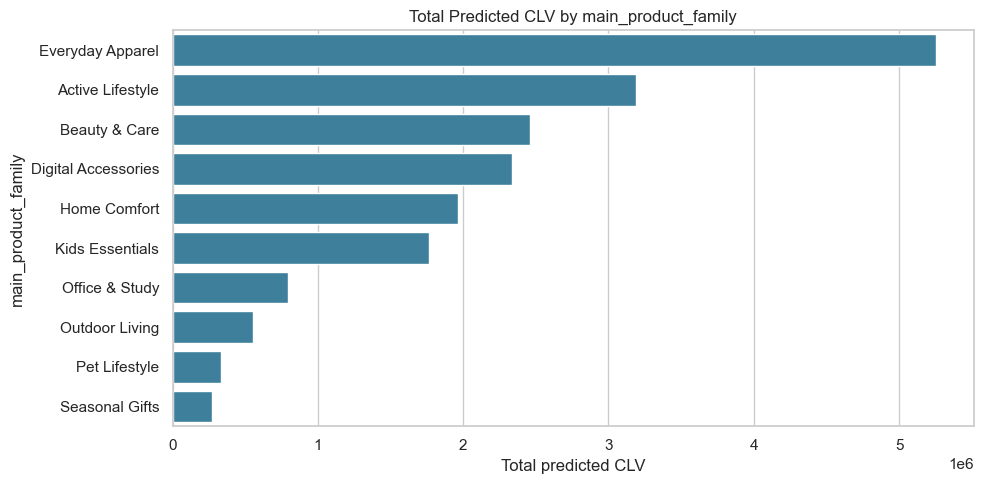

,main_channel,customers,total_predicted_clv,avg_predicted_clv,avg_return_rate,avg_frequency
0,direct_web,87551,"5,688,927.057",64.978,0.116,2.843
1,organic_search,55882,"3,249,973.632",58.158,0.124,2.626
2,paid_search,53657,"3,048,362.654",56.812,0.132,2.575
3,email_campaign,45854,"2,456,335.234",53.569,0.113,2.546
4,social_media,38912,"1,994,166.505",51.248,0.147,2.405
5,affiliate_partner,30126,"1,531,830.127",50.847,0.133,2.478
6,marketplace,21053,"956,911.982",45.453,0.141,2.285


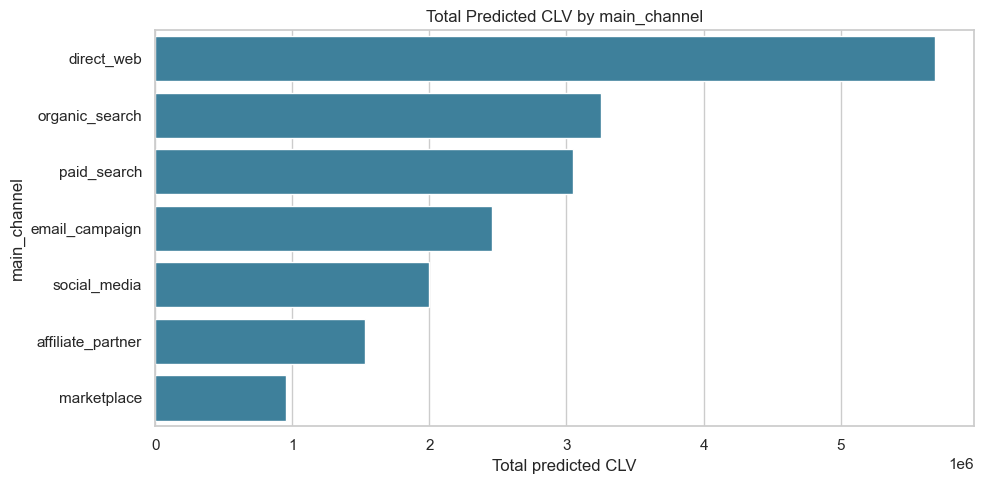

,loyalty_tier,customers,total_predicted_clv,avg_predicted_clv,avg_return_rate,avg_frequency
0,gold,64656,"7,736,165.685",119.651,0.125,3.912
1,silver,114890,"6,079,998.243",52.920,0.127,2.609
2,platinum,16846,"3,256,692.978",193.321,0.111,5.217
3,bronze,101945,"1,701,142.497",16.687,0.128,1.780
4,new,34698,"152,507.788",4.395,0.127,1.295


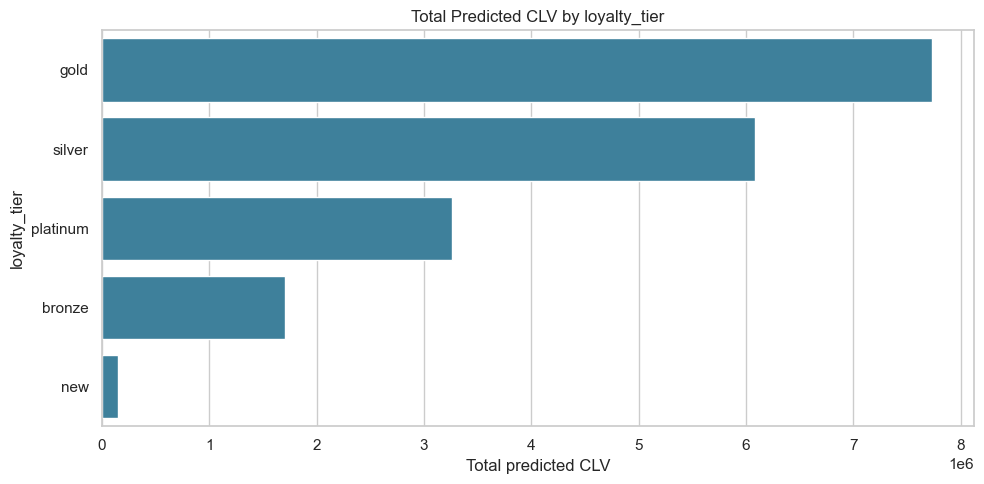

,customer_region,customers,total_predicted_clv,avg_predicted_clv,avg_return_rate,avg_frequency
0,Central Plains,71454,"3,872,772.626",54.200,0.126,2.578
1,Coastal Belt,57715,"3,229,064.033",55.948,0.126,2.588
2,Eastvale,47688,"2,713,004.741",56.891,0.128,2.594
3,Highland,40504,"2,274,851.480",56.164,0.126,2.591
4,Metro Core,34450,"1,988,670.831",57.726,0.125,2.599
5,Northlake,30522,"1,789,761.859",58.638,0.127,2.638
6,Southridge,26690,"1,600,421.718",59.963,0.126,2.641
7,Westport,23765,"1,454,493.981",61.203,0.126,2.690
8,Unknown,247,"3,465.923",14.032,0.101,0.899


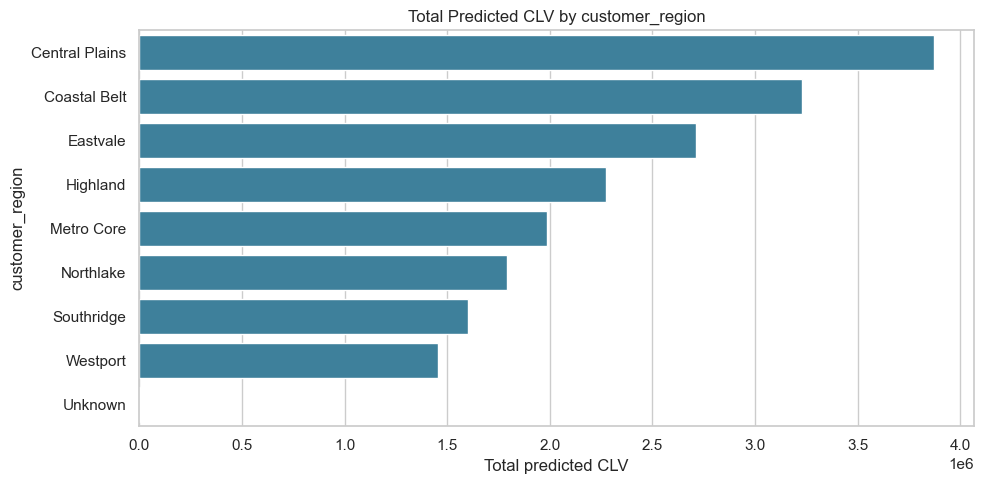

In [29]:
group_analysis_cols = ["main_product_family", "main_channel", "loyalty_tier", "customer_region"]

for col in group_analysis_cols:
    if col in customer_clv_scores.columns:
        summary = (
            customer_clv_scores.groupby(col)
            .agg(
                customers=(SCHEMA["customer_id"], "nunique"),
                total_predicted_clv=("predicted_future_clv_euros", "sum"),
                avg_predicted_clv=("predicted_future_clv_euros", "mean"),
                avg_return_rate=("return_rate", "mean"),
                avg_frequency=("frequency", "mean"),
            )
            .sort_values("total_predicted_clv", ascending=False)
            .head(20)
            .reset_index()
        )

        display(summary)

        plt.figure(figsize=(10, 5))
        sns.barplot(data=summary.head(15), x="total_predicted_clv", y=col, color="#2E86AB")
        plt.title(f"Total Predicted CLV by {col}")
        plt.xlabel("Total predicted CLV")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()


**Product, channel, and loyalty interpretation**

Everyday Apparel contributes the largest total predicted CLV at about **€5.25M**, but it also has the highest average return rate among the listed product families. Direct web contributes the largest channel-level predicted value at about **€5.69M**, with stronger average value than the other channels.

The loyalty view is more concentrated: gold customers contribute the largest total predicted CLV, while platinum customers have the highest average predicted CLV. This suggests that both scale and per-customer value matter when planning CRM activity.


,product_family_count,customers,avg_predicted_clv,avg_return_rate,avg_frequency
0,1,72556,13.536,0.130,0.910
1,2,61899,19.775,0.129,1.394
2,3,52204,29.204,0.129,1.900
3,4,42755,43.162,0.126,2.482
4,5,34422,63.718,0.125,3.205
5,6,26353,93.832,0.121,4.105
6,7,18728,136.237,0.120,5.236
7,8,12946,197.373,0.116,6.676
8,9,7802,280.971,0.111,8.603
9,10,3370,411.125,0.107,11.619


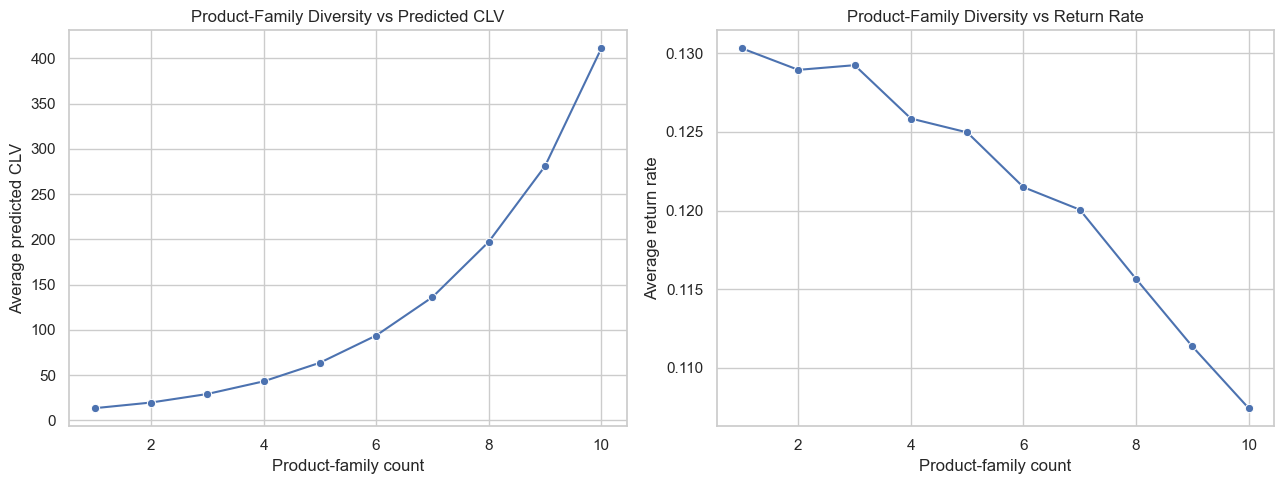

In [30]:
if "product_family_count" in customer_clv_scores.columns:
    diversity_summary = (
        customer_clv_scores.groupby("product_family_count")
        .agg(
            customers=(SCHEMA["customer_id"], "nunique"),
            avg_predicted_clv=("predicted_future_clv_euros", "mean"),
            avg_return_rate=("return_rate", "mean"),
            avg_frequency=("frequency", "mean"),
        )
        .reset_index()
        .sort_values("product_family_count")
    )

    display(diversity_summary)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    sns.lineplot(data=diversity_summary, x="product_family_count", y="avg_predicted_clv", marker="o", ax=axes[0])
    axes[0].set_title("Product-Family Diversity vs Predicted CLV")
    axes[0].set_xlabel("Product-family count")
    axes[0].set_ylabel("Average predicted CLV")

    sns.lineplot(data=diversity_summary, x="product_family_count", y="avg_return_rate", marker="o", ax=axes[1])
    axes[1].set_title("Product-Family Diversity vs Return Rate")
    axes[1].set_xlabel("Product-family count")
    axes[1].set_ylabel("Average return rate")

    plt.tight_layout()
    plt.show()


**Product-diversity interpretation**

Predicted CLV rises strongly with product-family diversity. Customers active in one family average about **€13.54** in predicted future CLV, while customers active across ten families average about **€411.13**. This does not prove that buying more categories causes higher CLV, but it is a useful engagement signal. Broader product-family activity appears to identify customers with stronger future value and slightly lower return behavior.


**Customer-value interpretation**

The highest predicted CLV customers are all in the **Very High Value** band, but they are not identical. Some high-value customers show return rates above **20%**, while the lower-return high-value examples have return rates of **0%** in the observation window. This difference matters. High predicted value is useful for prioritization, but return behavior should still be reviewed before treating all high-value customers the same.


# 19. Save Best CLV Model and Artifacts


In [31]:
def safe_min(values):
    return min(values) if len(values) > 0 else None


def safe_max(values):
    return max(values) if len(values) > 0 else None


model_metadata = {
    "model_name": best_model_name,
    "feature_cols": feature_cols,
    "target_definition": "future_realized_clv = sum(realized_revenue) in the prediction window",
    "observation_days": OBSERVATION_DAYS,
    "prediction_days": PREDICTION_DAYS,
    "snapshot_freq": SNAPSHOT_FREQ,
    "number_of_snapshot_dates": int(model_df["snapshot_date"].nunique()),
    "split_strategy": split_strategy,
    "train_snapshot_dates": [str(x) for x in train_snapshot_dates],
    "test_snapshot_dates": [str(x) for x in test_snapshot_dates],
    "train_snapshot_start": str(safe_min(train_snapshot_dates)) if safe_min(train_snapshot_dates) is not None else None,
    "train_snapshot_end": str(safe_max(train_snapshot_dates)) if safe_max(train_snapshot_dates) is not None else None,
    "test_snapshot_start": str(safe_min(test_snapshot_dates)) if safe_min(test_snapshot_dates) is not None else None,
    "test_snapshot_end": str(safe_max(test_snapshot_dates)) if safe_max(test_snapshot_dates) is not None else None,
    "train_row_count": int(len(train_df)),
    "test_row_count": int(len(test_df)),
    "clv_band_method": "quantile_based_qcut_4_bands",
    "model_comparison": model_comparison,
}

model_path = MODEL_DIR / "best_customer_clv_model.joblib"
metadata_path = MODEL_DIR / "customer_clv_metadata.joblib"
comparison_path = OUTPUT_DIR / "customer_clv_model_comparison.csv"
scores_parquet_path = OUTPUT_DIR / "customer_clv_scores.parquet"
scores_csv_path = OUTPUT_DIR / "customer_clv_scores.csv.gz"
summary_path = OUTPUT_DIR / "customer_clv_summary.csv"

joblib.dump(best_model, model_path)
joblib.dump(model_metadata, metadata_path)

model_comparison.to_csv(comparison_path, index=False)
customer_clv_scores.to_parquet(scores_parquet_path, index=False)
customer_clv_scores[score_columns].to_csv(scores_csv_path, index=False, compression="gzip")
clv_band_summary.to_csv(summary_path, index=False)

print("Saved artifacts:")
print("-", model_path.as_posix())
print("-", metadata_path.as_posix())
print("-", comparison_path.as_posix())
print("-", scores_parquet_path.as_posix())
print("-", scores_csv_path.as_posix())
print("-", summary_path.as_posix())


Saved artifacts:
- models/best_customer_clv_model.joblib
- models/customer_clv_metadata.joblib
- outputs/customer_clv_model_comparison.csv
- outputs/customer_clv_scores.parquet
- outputs/customer_clv_scores.csv.gz
- outputs/customer_clv_summary.csv


# 20. Ad Hoc Business Reasoning Checks


---
## Q1: Which customer group should CRM prioritize first?

The **Very High Value** band is the first group to review. It contains about **83K customers** and represents roughly **€13.87M** in predicted future CLV, or about **73%** of total predicted value in the scoring output. This group also has stronger behavior quality than the lower bands: average recency is about **19 days**, average frequency is about **5.46**, and average return rate is about **11.1%**. It is the clearest group for loyalty, retention, and high-value customer review.


---
## Q2:  Are the highest predicted CLV customers always the cleanest value group?

Not always. The Very High Value band has the lowest average return rate overall, but the detailed customer lists still show high-value customers with return rates above **20%**. Those customers should not be excluded automatically, but they should be reviewed differently from high-value customers with zero or very low return behavior. Return-adjusted value is more useful than predicted value alone.

---
## Q3: Does the model rank future value well enough to support prioritization?

Yes, for group-level prioritization. In the test set, the bottom predicted decile averages about **€19** in actual future CLV, while the top predicted decile averages about **€321**. The top predicted decile captures about **27%** of actual future CLV, and the top three predicted deciles capture about **58%**. That is a practical ranking signal, even though individual customer-level euro predictions remain uncertain.


---
## Q4: Which customer profile is linked with stronger predicted value?

Broader product engagement is one of the clearest scoring patterns. Customers active in one product family average about **€13.54** in predicted future CLV, while customers active across ten product families average about **€411.13**. This suggests that product-family diversity is a useful engagement signal for customer-value planning. 